# run all neccessary functionalities

In [2]:
def extract_stock_data(df, tdickers, start, end):
    """
    Extract stock data for specific tickers between the start and end dates.

    Parameters:
    - df: pandas DataFrame with rows as dates (monthly) and columns as stock tickers.
    - tickers: list of tickers to extract data for.
    - start: start date (YYYY-MM-DD) for the data extraction.
    - end: end date (YYYY-MM-DD) for the data extraction.

    Returns:
    - pandas DataFrame with the specified tickers and date range.
    """
    # Ensure the date column is in datetime format
    df.index = pd.to_datetime(df.index)
    df.index=df.index.to_period('M').to_timestamp('D')
    # Filter the DataFrame for the date range
    df_filtered = df.loc[start:end]

    # Select the tickers from the DataFrame
    df_selected = df_filtered[tdickers]
    df_selected=df_selected.loc[:, df_selected.isna().sum() <= 0].dropna()
    # df_selected.interpolate(method='linear',inplace=True)
    df_selected.index = pd.to_datetime(df_selected.index)
    df_selected = df_selected.tz_localize(None)
    columns = sorted([col for col in df_selected.columns if col != 'Date'])
    df_selected=df_selected[columns]
    for col in df_selected.columns:
        try:
            df_selected[col] = df_selected[col].astype(float)
        except ValueError:
            print(f"Column '{col}' could not be converted to float.")
    df_selected.index=df_selected.index.to_period('M').to_timestamp('D')
    df_selected.replace('C', np.nan, inplace=True)    
    for col in df_selected.columns:
            try:
                df_selected[col] = df_selected[col].astype(float)
            except ValueError:
                print(f"Column '{col}' could not be converted to float.")
    df_selected.interpolate(method='linear',inplace=True)
    df_selected = df_selected.fillna(method='ffill')
    df_selected = df_selected.fillna(method='bfill')
    return df_selected



In [3]:


def extract_spy_data(df, start, end):
    df.index = pd.to_datetime(df.index)
    df.index=df.index.to_period('M').to_timestamp('D')
    df_filtered = df.loc[start:end]
    return df_filtered



In [ ]:
ticks = spy_yoy_tickers.loc[2017].tolist()
ticks1 = spy_yoy_tickers.loc[2025].tolist()
len(list(set(ticks) & set(ticks1)))


330

In [52]:
# Creates tickers ([]), monthly_data (DF), and base_w ([])
def get_spy2(start,end):
    
    ### Get tickers + setup
    global tickers,spy
    valid_tickers = []

    new_monthly_data1 = new_monthly_data.copy()
    new_monthly_data1.index = pd.to_datetime(new_monthly_data1.index)
    spy_year1 = (pd.to_datetime(start)).year
    print(spy_year1)
    spy_year2 = (pd.to_datetime(start) + relativedelta(years = 4)).year
    if spy_year2 >= 2025:
        spy_year2 = 2024
    print(spy_year2)

    subset_ticks = spy_yoy_tickers.loc[spy_year1:spy_year2]
    subset_ticks = [set(row.dropna()) for _, row in subset_ticks.iterrows()]
    tickers = set.intersection(*subset_ticks)
    
    for tick in tickers:
        if tick not in new_monthly_data1.columns:
            continue
        if(new_monthly_data1[tick].loc[str(spy_year1) : str(spy_year2)].isna().any()):
            continue
        valid_tickers.append(tick)
    tickers =  valid_tickers
    print(len(tickers))
    ### Import the monthly data
    global monthly_data
    global base_w
    monthly_data = extract_stock_data(new_monthly_data,tickers,start=start,end=end)
    
    
    
     # Reformat Date Index 
    '''
    Structure of monthly_data:
    rows: new date
    columns: various tickers drawn from the S&P 500
    '''

    # Assign equal weight as base weights
    base_w = {k: 1/len(monthly_data.columns) for k in monthly_data.columns}
    base_w = pd.DataFrame.from_dict(base_w, orient='index', columns=['Weight'])

    spy=extract_spy_data(indexgspc,start,end)
    print(monthly_data.index.equals(spy.index))
    if monthly_data.index.equals(spy.index)==True:
        for i,j in monthly_data.iterrows():
            monthly_data.loc[i,'SP_500']=spy.loc[i,'SP_500']
    # Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    tickers = list(monthly_data.columns[:-1]) 
    tick_index = tickers + ['SP_500']


In [208]:
opt_portf_weights.index

Index(['AAPL', 'ABT', 'ADP', 'ALGN', 'AMAT', 'AMZN', 'CB', 'CHTR', 'CME',
       'DPZ', 'DVA', 'EPAM', 'ESS', 'FDX', 'FIS', 'GOOGL', 'GRMN', 'HSY',
       'HUM', 'IBM', 'ILMN', 'JPM', 'MSCI', 'MSFT', 'MTB', 'MTD', 'PAYC', 'PG',
       'PYPL', 'QCOM', 'RJF', 'STE', 'TRV', 'TSLA', 'TTWO', 'VRSK'],
      dtype='object', name='Ticker')

In [207]:
oos1_daily_data.columns

Index(['ADBE', 'AMZN', 'ANSS', 'AVGO', 'CHTR', 'CLX', 'CME', 'DVA', 'ESS',
       'ETSY', 'GS', 'HUM', 'ILMN', 'LMT', 'LRCX', 'MMM', 'MTB', 'NFLX', 'NSC',
       'ORCL', 'PNC', 'REGN', 'ROP', 'SNA', 'SNPS', 'STZ', 'TDG', 'TFX', 'TGT',
       'TSLA', 'TTWO', 'TYL', 'ULTA', 'VRSK', 'VRSN', 'WMT', 'SP_500',
       'Optimized Portfolio'],
      dtype='object', name='Ticker')

In [72]:
stop = pd.to_datetime('2015-12-31')
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,1.0,0.7,0.7,'rebalance',3,15, stop)

2007
2011
301
True
2008
2012
319
True
2009
2013
335
True
2010
2014
353
True
2011
2015
354
True
2012
2016
354
True
2013
2017
350
True
2014
2018
353
True
Column 'FTI' could not be converted to float.
Column 'FTI' could not be converted to float.
2015
2019
355
Column 'FTI' could not be converted to float.
True
2016
2020
371
Column 'FTI' could not be converted to float.
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True


In [73]:
performance_metrics(oos1_list[0], .0243)

,Cumulative Return,Annualized Return,Observed Volatility,Downside Volatility,Sharpe,Sortino
Ticker,,,,,,
SP_500,3.887161,0.112893,0.141175,0.090447,0.661012,1.031751
Optimized Portfolio,5.065358,0.129216,0.200685,0.128922,0.590523,0.919230


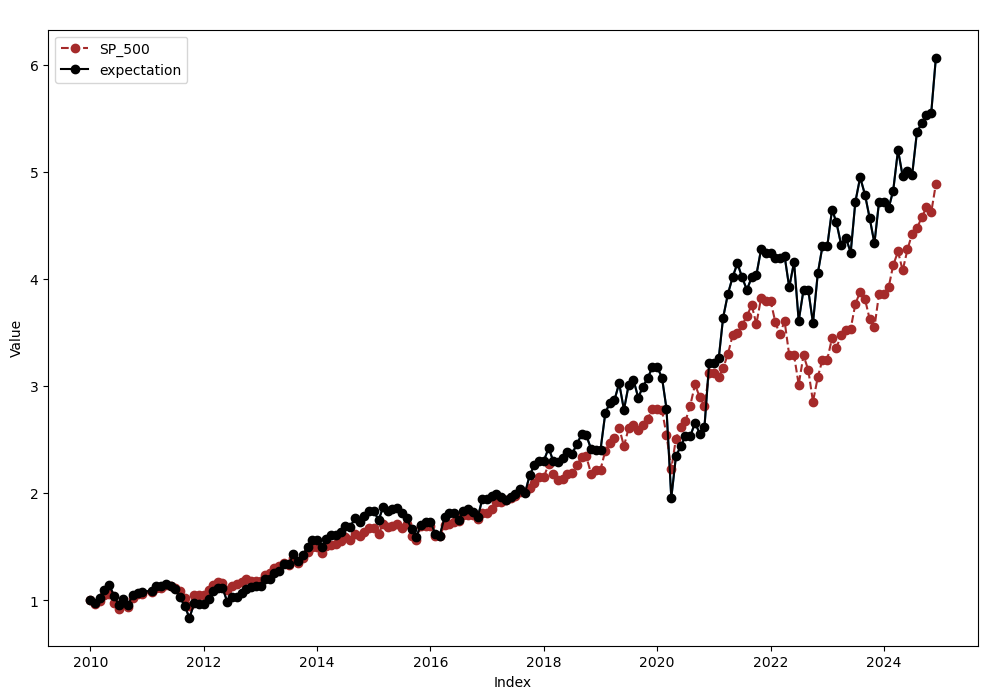

,SP_500,Optimized Portfolio
Date,,
2010-01-01,1.000000,1.000000
2010-02-01,0.963026,0.977908
2010-03-01,0.990486,1.023099
2010-04-01,1.048722,1.097071
2010-05-01,1.064200,1.148524
...,...,...
2024-08-01,4.473918,5.371957
2024-09-01,4.576080,5.455134
2024-10-01,4.668503,5.529995


In [74]:
final_visual()

In [67]:
oos1_list[0].style.set_sticky()

Ticker,SP_500,Optimized Portfolio
Date,,
2020-01-01 00:00:00,1.000000,1.000000
2020-02-01 00:00:00,0.998372,0.981348
2020-03-01 00:00:00,0.914399,0.906224
2020-04-01 00:00:00,0.799990,0.759899
2020-05-01 00:00:00,0.901464,0.882008
2020-06-01 00:00:00,0.942284,0.938406
2020-07-01 00:00:00,0.959611,0.945319
2020-08-01 00:00:00,1.012487,0.948163
2020-09-01 00:00:00,1.083426,1.010081


In [5]:
# Creates tickers ([]), monthly_data (DF), and base_w ([])
def get_spy2(start,end):
    ### Get tickers + setup
    global tickers,spy
    requests.packages.urllib3.disable_warnings()
    # Fetch HTML content
    response = requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', verify=False)
    html_content = response.content
    # Read HTML content into pandas DataFrame
    list_of_dfs = pd.read_html(html_content)
    wikitable_sp_500 = list_of_dfs[0]
    sp500_symbols = wikitable_sp_500['Symbol']
    tickers = sp500_symbols.to_list() 
    print('\n\n\n',start,'\n\n\n')
    # Converting SP_500 tickers into list 
    # Remove some tickers as they create an error for the yfinance api
    # print('\namogus\n',tickers,'amogus\n')
    # tickers[65] = 'BRK-B'
    # tickers[81] = 'BF-B'
    try:
        tickers.remove('BF-B')
        tickers.remove('BRK-B')
    except:
        print('\n')
    try:
        tickers.remove('BRK.B')
        tickers.remove('BF.B')
    except:
        print('\n')

    ### Import the monthly data
    global monthly_data
    global base_w
    monthly_data = extract_stock_data(new_monthly_data,tickers,start=start,end=end)
    if 'GEN' in monthly_data.columns:
        monthly_data.drop(columns={'GEN'},inplace=True)
    if 'COR' in monthly_data.columns:
        monthly_data.drop(columns={'COR'},inplace=True)
    if 'FI' in monthly_data.columns:
        monthly_data.drop(columns={'FI'},inplace=True)    
    if 'BKNG' in monthly_data.columns:
        monthly_data.drop(columns={'BKNG'},inplace=True)
    if 'KEYS' in monthly_data.columns:
        monthly_data.drop(columns={'KEYS'},inplace=True)
    if 'MS' in monthly_data.columns:
        monthly_data.drop(columns={'MS'},inplace=True)
    if 'AXON' in monthly_data.columns:
        monthly_data.drop(columns={'AXON'},inplace=True)
    if 'ELV' in monthly_data.columns:
        monthly_data.drop(columns={'ELV'},inplace=True)
    if 'EXE' in monthly_data.columns:
        monthly_data.drop(columns={'EXE'},inplace=True)
    if 'HCA' in monthly_data.columns:
        monthly_data.drop(columns={'HCA'},inplace=True)
    if 'HRL' in monthly_data.columns:
        monthly_data.drop(columns={'HRL'},inplace=True)
    if 'V' in monthly_data.columns:
        monthly_data.drop(columns={'V'},inplace=True)
    if 'KVM' in monthly_data.columns:
        monthly_data.drop(columns={'KVM'},inplace=True)
    if 'KMI' in monthly_data.columns:
        monthly_data.drop(columns={'KMI'},inplace=True)  
    if 'GM' in monthly_data.columns:
        monthly_data.drop(columns={'GM'},inplace=True)
    if 'MNST' in monthly_data.columns:
        monthly_data.drop(columns={'MNST'},inplace=True)   
    if 'BKR' in monthly_data.columns:
        monthly_data.drop(columns={'BKR'},inplace=True) 
    
     # Reformat Date Index 
    # # monthly_data = monthly_data['Adj Close'].pct_change() # Turn Adj Close prices into pct returns
    # monthly_data = monthly_data.drop(monthly_data.index[0]) #Drop First row NaN values
    # monthly_data = monthly_data.dropna(axis=1) # Drop if stock doesnt have data starting from the first index date
    
    

    '''
    Structure of monthly_data:
    rows: new date
    columns: various tickers drawn from the S&P 500
    '''

    # Assign equal weight as base weights
    base_w = {k: 1/len(monthly_data.columns) for k in monthly_data.columns}
    base_w = pd.DataFrame.from_dict(base_w, orient='index', columns=['Weight'])
    # Getting SP_500 data
    # spy = pd.DataFrame(yf.download('^GSPC',start=start,end=end,interval='1mo')['Adj Close'].pct_change())#Dropping First Row(NaN) and formatting index to match monthly_data 
    # spy = spy.drop(spy.index[0]).tz_localize(None)
    # monthly_data['SP_500'] = spy['Adj Close'] # Adding SP_500 data to monthly_data
    # for col in monthly_data.columns:
    #     monthly_data[col]=monthly_data[col].astype(float)
    # monthly_data.index=monthly_data.index.to_period('M').to_timestamp('D')
    spy=extract_spy_data(indexgspc,start,end)
    print(monthly_data.index.equals(spy.index))
    if monthly_data.index.equals(spy.index)==True:
        for i,j in monthly_data.iterrows():
            monthly_data.loc[i,'SP_500']=spy.loc[i,'SP_500']
    # spy = pd.DataFrame(yf.download('^GSPC',start=start,end=end,interval='1mo')['Adj Close'].pct_change())#Dropping First Row(NaN) and formatting index to match monthly_data 
    # spy = spy.drop(spy.index[0]).tz_localize(None)#Adding SP_500 data to monthly_data
    # Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    tickers = list(monthly_data.columns[:-1]) 
    tick_index = tickers + ['SP_500']
    # return spy

In [6]:
def download_with_retry(tickers, start, end, retries=3, delay=5):
    for attempt in range(retries):
        try:
            return extract_stock_data(new_monthly_data,tickers, start=start, end=end)
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(delay)
    raise Exception(f"Failed to download data after {retries} attempts.")


In [7]:
def get_spy(beta1,beta2,beta3,start,end):
  
    global tickers
    requests.packages.urllib3.disable_warnings() 
    # Fetch HTML content
    response = requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', verify=False)
    html_content = response.content
    # Read HTML content into pandas DataFrame
    list_of_dfs = pd.read_html(html_content)
    wikitable_sp_500 = list_of_dfs[0]
    sp500_symbols = wikitable_sp_500['Symbol']#Converting SP_500 tickers into list 
    tickers = sp500_symbols.to_list()#Remove some tickers as they create an error for the yfinance api
    tickers[65] = 'BRK-B'
    tickers[81] = 'BF-B'
    tickers.remove('BF-B')
    tickers.remove('BRK-B')#Start Date for In Sample Historical Data
    global monthly_data
    global base_w
    monthly_data = extract_stock_data(new_monthly_data,tickers,start=start,end=end)#Reformat Date Index 
    monthly_data.index = pd.to_datetime(monthly_data.index)
    monthly_data = monthly_data.tz_localize(None)#Turn Adj Close prices into pct returns
    monthly_data.index=monthly_data.index.to_period('M').to_timestamp('D')
    # monthly_data = monthly_data['Adj Close'].pct_change()#Drop First row NaN values
    # monthly_data = monthly_data.drop(monthly_data.index[0])#Drop if stock doesnt have data starting from the first index date
    # monthly_data = monthly_data.dropna(axis=1)#Assign equal weight as base weights
    
    base_w = {k: 1/len(monthly_data.columns) for k in monthly_data.columns}
    base_w = pd.DataFrame.from_dict(base_w, orient='index', columns=['Weight'])#Getting SP_500 data
    spy=extract_spy_data(indexgspc,start,end)
    # spy = pd.DataFrame(yf.download('^GSPC',start=start,end=end,interval='1mo')['Adj Close'].pct_change())#Dropping First Row(NaN) and formatting index to match monthly_data 
    # spy = spy.drop(spy.index[0]).tz_localize(None)#Adding SP_500 data to monthly_data
    monthly_data['SP_500'] = spy['SP_500']
    #Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    
    tickers = list(monthly_data.columns[:-1])
    tick_index = tickers + ['SP_500']

    

In [8]:
def famafrenchreturns():
    global ff3_monthly
    # Fama French Monthly Returns Data using getFamaFrenchFactors module
    ff3_monthly = gff.famaFrench3Factor(frequency='m')
    ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
    ff3_monthly.set_index('Date', inplace=True)
    ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
    # Keeping Only the Dates in the monthly_data
    ff3_monthly = ff3_monthly.loc[monthly_data.index]
    

In [9]:

def to__cal_stock_betas():
    global stock_betas
    stock_betas = pd.DataFrame()
    # Iterate over the tickers list
    for col in monthly_data.columns:
        # Set the dependent variable (Return of stock i)
        y = monthly_data[col]
        # Set the independent variables (Fama French 3 Factors)
        X = ff3_monthly[['Mkt-RF','SMB','HML']]
        # Fit the multiple linear regression model
        model = LinearRegression()
        model.fit(X, y)
        # Store the results in the DataFrame
        stock_betas[col] = [model.intercept_] + list(model.coef_)
    stock_betas = stock_betas.T
    stock_betas.columns = ['Intercept','Mkt-RF','SMB','HML']

In [10]:
def to_cal_stock_price(startt,endd):
    global stock_price
    global s_price
    global s_keys
    global s_values
    #Stock Prices on the Day of Optimization(Rebalancing)
    stock_price = extract_stock_data(price_monthly_data,tickers,start=startt,end=endd)
    stock_price = stock_price[-1:]
    stock_price.index = pd.to_datetime(stock_price.index).tz_localize(None)
    s_price = {}
    s_keys = list(tickers)
    s_values =  list(stock_price.iloc[0])
    for key,value in zip(s_keys,s_values):
        s_price[key] = value

In [11]:
def Transaction_Costs(initialize=False):
    if initialize:
        random.seed(1)  # Set seed only during initialization
    global t_cost
    t_cost = {}
    global keys
    keys = list(tickers)
    values = list(random.uniform(.01, .02) for i in range(len(tickers)))
    for key, value in zip(keys, values):
        t_cost[key] = value


In [12]:
def optimization():
# OPTIMIZATION MODEL
    global index
    global wei
    global aux
    global err
    global binary
    global tr_cost
    global shares
    index = LpProblem('Index', LpMinimize) 
    # Decision Variables
    wei = LpVariable.dicts('Weight',tickers,lowBound=0)                           # Weights for stock i in the optimal portfolio
    aux = LpVariable.dicts('Y',tickers,lowBound=0)                                # Absolute value of change for stock i from base weights
    err = LpVariable.dicts('Error', monthly_data.index, lowBound=0)               # Error term for portfolio
    binary = LpVariable.dicts('bin',tickers,cat=LpBinary)                         # Used if we want to limit the # of stocks we want to have in optimal portfolio
    tr_cost = LpVariable.dicts('Transaction_Cost',tickers,lowBound=0)             # Total Transaction cost for stock i in the optimal portfolio
    shares = LpVariable.dicts('shares',tickers,lowBound=0)                        # Total Transaction cost for stock i in the optimal portfolio
    #Objective Function - Minimize the error term 
    index +=  lpSum(err[t] for t in monthly_data.index) # Constraint: Weights sum to 1 
    index += lpSum(wei[i] for i in tickers) == 1
    # Constraint: Absolute value of change in weights from base weigths
    for i in tickers:
        index += aux[i] >= base_weights[i]  - wei[i]
        index += aux[i] >= wei[i] - base_weights[i]
    index += lpSum(aux[i] for i in tickers) <= 1 
    # Constraint: Error term
    for t in monthly_data.index:
        index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) - err[t] <= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])
        index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) + err[t] >= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])
    # Shares
    for i in tickers:
        index += shares[i] == (aux[i]*B/s_price[i])
    # Transaction Costs
    for i in tickers:
        index += lpSum(aux[i] *B*t_cost[i]/s_price[i]) == tr_cost[i]
    index += lpSum(tr_cost[i] for i in tickers) <= 2000
    # Limit # of stocks in Optimal Portfolio
    for i in tickers: # Forces weight of stock i to be less than binary value of stock i. If stock is not selected binary variable is 0 which then forces weight of stock i to be in the optimal portfolio to be 0.
        index += wei[i] <= binary[i]
    index += lpSum(binary[i] for i in tickers) <= q
    index.solve()
    

In [13]:
def others():
    global sharess
    #Change in number of shares
    sharess = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 's'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 's'] , columns = ['Optimal'])
    sharess
    global tr_cost
    #Transaction Costs
    tr_cost = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'T'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'T'] , columns = ['Optimal'])
    tr_cost.sum()
    global weii
    #Optimal weights
    weii = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'W'] , columns = ['Optimal'])
    weii.sum()
    global auxx
    #Change of weights
    auxx = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'Y'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'Y'] , columns = ['Optimal'])
    auxx.sum()
    global errr
    #Error terms
    errr = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'E'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'E'] , columns = ['Optimal'])
    errr.sum()
    global binary_v
    # Check if Binary Values Constraint works
    binary_v = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'] , columns = ['Optimal'])
    binary_v.sum()
    global opt_weights 
    # Weights in Optimal Portfolio
    opt_weights = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'] , columns = ['Optimal'])
    
    opt_weights.style.format('{:,.2%}'.format)
    global weights_new
    weights_new = pd.DataFrame([v.varValue for v in index.variables() if str(v.name[0]) == 'W'], index = [str(v.name).split('_')[1] for v in index.variables() if str(v.name[0]) == 'W'] , columns = ['New Weights'])
    global weights
    weights = pd.DataFrame(np.zeros((len(monthly_data.columns[:-1]),3)), index=monthly_data.columns[:-1], columns=['PORTFOLIO Weights','Difference','New Weights'])
    for t in monthly_data.columns[:-1]:
        weights.loc[t][0] = base_w.loc[t]
        weights.loc[t][1] = weights_new.loc[t][0]-base_w.loc[t][0]
        weights.loc[t][2] = weights_new.loc[t]
    weights
    columns_to_remove = ['PORTFOLIO Weights', 'Difference']
    # Specify the column to filter non-zero values
    column_to_filter = 'New Weights'
    # Create a new DataFrame with selected columns and rows where New Weights is not equal to 0
    global opt_portf_weights
    opt_portf_weights = weights.drop(columns=columns_to_remove)[weights[column_to_filter] != 0]




In [14]:
def portfolio_betas():
    # CHECK PORTFOLIO BETAS
   
    global port_betas
    port_returns = pd.DataFrame(np.zeros((len(monthly_data.index),2)), index=monthly_data.index, columns=["SP_500","Optimization"])
    for j in port_returns.index:
        port_returns.loc[j]["SP_500"] = monthly_data.loc[j]['SP_500']
        port_returns.loc[j]['Optimization'] = monthly_data.loc[j,:monthly_data.columns[-2]].dot(weights['New Weights'])
    port_returns = port_returns.merge(ff3_monthly[['Mkt-RF','SMB','HML']], left_index=True, right_index=True)
    # Create an empty DataFrame to store the Portfolio Beta
    port_betas = pd.DataFrame(np.zeros((3,4)), index=ff3_monthly.columns[0:3], columns=["SP_500", "Target", "Optimization", "Abs. Diff"])
    port_betas["Target"] = [mkt_opt, smb_opt, hml_opt]# Set the independent variables (Fama French 3 Factors)
    X = port_returns[['Mkt-RF','SMB','HML']]
    # Set the dependent variable (Return of Portfolio)
    Y = port_returns['SP_500']# Fit the multiple linear regression model
    regr = LinearRegression()
    regr.fit(X,Y)
    port_betas['SP_500'] = regr.coef_
    # Set the dependent variable (Return of Portfolio)
    Y = port_returns['Optimization']
    # Fit the multiple linear regression model
    regr = LinearRegression()
    regr.fit(X,Y)
    port_betas['Optimization'] = regr.coef_
    # Abs Difference between Target Betas & Optimal Portfolio Betas
    port_betas["Abs. Diff"] = round(abs(port_betas['Optimization'] - port_betas["Target"]),4)
    port_betas
    return port_betas
    

In [15]:
def simulator(beta1,beta2,beta3,begin,final,budget,number):
    global start
    global end
    start=begin
    end = final
    get_spy2(start,end)
    #Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    global tickers
    tickers = list(monthly_data.columns[:-1])
    tick_index = tickers + ['SP_500']
    

    # TARGET FACTOR BETAS 
    global base_weights
    global mkt_opt
    global smb_opt
    global hml_opt
    global B
    global q
    
    mkt_opt = beta1                          # TARGET MKT BETA - EXPOSURE OF THE NEW PORTFOLIO TO MARKET FACTOR 
    smb_opt = beta2                           # TARGET SMB BETA - EXPOSURE OF THE NEW PORTFOLIO TO SIZE FACTOR 
    hml_opt = beta3                           # TARGET HML BETA - EXPOSURE OF THE NEW PORTFOLIO TO VALUE FACTOR 
    B = budget                             # BUDGET
    q = number                                # NUMBER OF STOCKS IN THE NEW PORTFOLIO
    base_weights = base_w.T*0               # ONLY HAVE THIS LINE OF CODE WHEN YOU ARE CONSTRUCTING THE PORTFOLIO FROM SCRATCH 
    
    famafrenchreturns()
    to__cal_stock_betas()
    to_cal_stock_price(start,end)
    Transaction_Costs()
    optimization()
    others()
    portfolio_betas()
    opt_portf_weights
    global port_betas
    opt_portf_weights


In [16]:
def out_of_sampless(cccc,dddd):
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = cccc
    o1_end_d   = dddd
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,cccc,dddd)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    # oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [18]:
def out_of_sample():
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    # oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,os_start,os_end)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(init,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(init,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [17]:
def out_of_sample(initializer):
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    # oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,os_start,os_end)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    if initializer == True:
        init = 1
    else:
        init = 0
    for j in range(init,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(init,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [17]:
def out_of_sample():
    global oos1_daily_data
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    # oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,os_start,os_end)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [19]:
def new_mod_out_of_sample1(hsahs,hsahs2):
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_start_d
    global o1_end_d
    o1_start_d = hsahs
    # last_key = list(out_of_sample_year_end.keys())[-1]
    o1_end_d   = hsahs2
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [20]:
def mod_out_of_sample1():
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_start_d
    global o1_end_d
    o1_start_d = out_of_sample_year_start[1]
    last_key = list(out_of_sample_year_end.keys())[-1]
    o1_end_d   = out_of_sample_year_end[last_key]
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [21]:
def mod_out_of_sample():
    global oos1_daily_data
    global oos1_new_performance
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [22]:
def run_with_backtest(nyears):
    
    global n_years
    n_years=nyears
    current_date()
    simulator(1,0,0,n_year_before,n_year_after,1000000,50) 
    out_of_sample()
  
    return oos1_new_performance
    
    


In [23]:
def current_date():
    global today
    global os_start
    global os_end
    global n_year_before
    global n_year_after
    from datetime import datetime, timedelta
    today = datetime.today()
    one_year_before = today - timedelta(days=365)
    os_start = today - timedelta(days=365)
    two_months_before = os_start - timedelta(days=2*30)
    os_start = two_months_before.replace(day=1)
    one_month_before = today - timedelta(days=30)
    os_end = one_month_before.replace(day=1)
    
    n_year_before = os_start - timedelta(days=(365*n_years))
    n_year_after=n_year_before+timedelta(days=(365*n_years))                           
    os_start=os_start.strftime("%Y-%m-%d")
    os_end=os_end.strftime("%Y-%m-%d")
    n_year_before=n_year_before.strftime("%Y-%m-%d")
    n_year_after=n_year_after.strftime("%Y-%m-%d")
    from datetime import date

    today = date.today()
    formatted_date = today.strftime("%Y-%m-%d")
    today = formatted_date


In [24]:
 for year in range(os_years):
        out_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * (os_years - year)))
        two_months_before = (out_of_sample_year_start[(year+1)] - timedelta(days=(3) * 30))
        out_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
(out_of_sample_year_start)

NameError: name 'os_years' is not defined

In [26]:
def new_date_calculation():
    from datetime import datetime, timedelta
    from datetime import date
    today = datetime.now()
    global out_of_sample_year_start
    global out_of_sample_year_end
    out_of_sample_year_start={}
    out_of_sample_year_end={}
    for year in range(os_years):
        out_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * (os_years - year)))
        two_months_before = (out_of_sample_year_start[(year+1)] - relativedelta(months = today.month-1))#- timedelta(days=(2) * 30))
        out_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=out_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        out_of_sample_year_end[(year+1)]=out_of_sample_year_start[(year+1)]+ timedelta(days=no_days_in_year-1)
        out_of_sample_year_start[(year+1)]=out_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        out_of_sample_year_end[(year+1)]=out_of_sample_year_end[(year+1)].strftime("%Y-%m-%d")                        
    
    global in_of_sample_year_start
    in_of_sample_year_start={}
    global in_of_sample_year_end
    in_of_sample_year_end={}
    for year in range(in_years):
        in_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * ((in_years+os_years) - year)))
        two_months_before = in_of_sample_year_start[(year+1)] - relativedelta(months = today.month-1)#timedelta(days=2 * 30)
        in_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=in_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        in_of_sample_year_end[(year+1)]=in_of_sample_year_start[(year+1)]+ timedelta(days=no_days_in_year-1)
        in_of_sample_year_start[(year+1)]=in_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        in_of_sample_year_end[(year+1)]=in_of_sample_year_end[(year+1)].strftime("%Y-%m-%d")
    
    inner_in_of_sample_year_start={}
    for year in range(in_years+os_years):
        inner_in_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * (in_years+os_years - year)))
        two_months_before = inner_in_of_sample_year_start[(year+1)] - - relativedelta(months = today.month-1) #timedelta(days=2 * 30)
        inner_in_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=inner_in_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        inner_in_of_sample_year_start[(year+1)]=inner_in_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        

    today = date.today()
    formatted_date = today.strftime("%Y-%m-%d")
    today = formatted_date
    return inner_in_of_sample_year_start

In [61]:
def new_run_with_backtest_rebalance(inyears,outyears,betaA,betaB,betaC):
    
    global start_date
    global end_date
    global os_years,tostorelist
    global in_years
    os_years=outyears
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    inner_n_year_before_cal=new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before=in_of_sample_year_start[1]
    n_year_after=in_of_sample_year_end[in_years]
    simulator(betaA,betaB,betaC,n_year_before,n_year_after,1000000,50)
    global checklist
    global rebalance_opt_weights
    global rebalance_sp500_weights 
    rebalance_sp500_weights = []
    rebalance_opt_weights = []
    checklist=[]
    tostorelist=[]
    noos1_new_performance=pd.DataFrame()
    for k in range(os_years): 
        initializer = False
        if k == 0:
            initializer = True
        global os_start
        global os_end
        global oos1_new_performances
        oos1_new_performances={}
        global init
        os_start=out_of_sample_year_start[1+k]
        os_end=out_of_sample_year_end[1+k]
        out_of_sample()
        checking=out_of_sample()
        tostorelist.append(checking)
        # mod_out_of_sample()
        checklist.append(oos1_new_performance)
        
        if k == 0:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1]
            start_date = os_start
            # multiplier=oos1_new_performance['Optimized Portfolio'][-1]
        else:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1] * performances[k]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1] * spy_performances[k]
        end_date = os_end 
            # oos1_new_performance['Optimized Portfolio']=oos1_new_performance['Optimized Portfolio']*multiplier
            # noos1_new_performance=pd.concat([noos1_new_performance, oos1_new_performance], ignore_index=False)
            # multiplier=noos1_new_performance['Optimized Portfolio'][-1]
        newbudget=1000000*oos1_new_performance['Optimized Portfolio'][-1]
        inner_n_year_before=inner_n_year_before_cal[k+2]
        inner_n_year_after=out_of_sample_year_end[1+k]
        
        simulator(betaA,betaB,betaC,inner_n_year_before,inner_n_year_after,newbudget,50) 
        rebalance_opt_weights.append(opt_weights)
        ##rebalance_sp500_weights.append(weights)
    checklist=extract_performance(checklist)
    noos1_new_performance=pd.concat(checklist, ignore_index=False)
    for kk in range(os_years): 
        placeholder=noos1_new_performance.index[0]
        # performances[k + 1] = oos1_new_performance.loc[placeholder,"SP_500"]
        # performances[k + 1] = oos1_new_performance.loc[placeholder,"Optimized Portfolio"]
        placeholder=placeholder.replace(year=placeholder.year+(kk+1))
        if placeholder in noos1_new_performance.index:
            new_spy_performances[kk + 1] = noos1_new_performance.loc[placeholder,"SP_500"]
            new_performances[kk + 1] = noos1_new_performance.loc[placeholder,"Optimized Portfolio"]
    
    new_spy_performances[os_years] = noos1_new_performance.iloc[-1].loc["SP_500"]
    new_performances[os_years] = noos1_new_performance.iloc[-1].loc["Optimized Portfolio"]
    return noos1_new_performance 
    
            
            
        

In [ ]:
def extract_performance(dflist):
    size=len(dflist)
    for i in range(size):
        eoy_performance=dflist[i]['Optimized Portfolio'][-1]
        eoy_spy=dflist[i]['SP_500'][-1]
        if i<(size-1):
            dflist[i+1]['Optimized Portfolio']=dflist[i+1]['Optimized Portfolio']*eoy_performance
            dflist[i+1]['SP_500']=dflist[i+1]['SP_500']*eoy_spy
    dflist[1]=dflist[1].iloc[1:]
    return dflist

In [28]:
def new_run_with_backtest(inyears,outyears,betaA,betaB,betaC):
    global start_date
    global end_date
    global os_years
    global in_years
    os_years=outyears
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before= in_of_sample_year_start[1]
    n_year_after= in_of_sample_year_end[in_years]
    
    simulator(betaA,betaB,betaC,n_year_before,n_year_after,1000000,50)
    global checklist
    checklist=[]
    for k in range(os_years): 
        global os_start
        global os_end
        global oos1_new_performances
        oos1_new_performances={}
        global init
        os_start=out_of_sample_year_start[1+k]
        os_end=out_of_sample_year_end[1+k]
        out_of_sample()
        # mod_out_of_sample()
        
        checklist.append(oos1_new_performance)
        if k == 0:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1]
            start_date = os_start
        else:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1] * performances[k]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1] * spy_performances[k]
    end_date = os_end

    mod_out_of_sample1()
    for kk in range(os_years): 
        placeholder=oos1_new_performance.index[0]
        # performances[k + 1] = oos1_new_performance.loc[placeholder,"SP_500"]
        # performances[k + 1] = oos1_new_performance.loc[placeholder,"Optimized Portfolio"]
        placeholder=placeholder.replace(year=placeholder.year+(kk+1))
        if placeholder in oos1_new_performance.index:
            new_spy_performances[kk + 1] = oos1_new_performance.loc[placeholder,"SP_500"]
            new_performances[kk + 1] = oos1_new_performance.loc[placeholder,"Optimized Portfolio"]
    
    new_spy_performances[os_years] = oos1_new_performance.iloc[-1].loc["SP_500"]
    new_performances[os_years] = oos1_new_performance.iloc[-1].loc["Optimized Portfolio"]
    return oos1_new_performance

In [29]:
def new_run_with_backtest_rebalance_stop(inyears,outyears,betaA,betaB,betaC, stop):
    
    global start_date
    global end_date
    global os_years,tostorelist
    global in_years
    os_years=outyears
    in_years=inyears
    performances={}
    spy_performances={}
    new_performances={}
    new_spy_performances={}
    inner_n_year_before_cal=new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before=in_of_sample_year_start[1]
    n_year_after=in_of_sample_year_end[in_years]
    simulator(betaA,betaB,betaC,n_year_before,n_year_after,1000000,50)
    global rebalance_opt_weights
    global rebalance_sp500_weights 
    rebalance_sp500_weights = []
    rebalance_opt_weights = []
    checklist=[]
    tostorelist=[]
    noos1_new_performance=pd.DataFrame()
    for k in range(os_years): 
        global os_start
        global os_end
        global oos1_new_performances
        oos1_new_performances={}
        global init
        os_start=out_of_sample_year_start[1+k]
        os_end=out_of_sample_year_end[1+k]
        print(os_start)
        out_of_sample()
        checking=out_of_sample()
        tostorelist.append(checking)
        checklist.append(oos1_new_performance)
        if(pd.to_datetime(os_end).year == stop.year):
            break
        if k == 0:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1]
            start_date = os_start
        else:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1] * performances[k]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1] * spy_performances[k]
        end_date = os_end 
        newbudget=1000000*oos1_new_performance['Optimized Portfolio'][-1]
        inner_n_year_before=inner_n_year_before_cal[k+2]
        inner_n_year_after=out_of_sample_year_end[1+k]
        
        simulator(betaA,betaB,betaC,inner_n_year_before,inner_n_year_after,newbudget,50) 
        rebalance_opt_weights.append(opt_weights)
        ##rebalance_sp500_weights.append(weights)
    checklist=extract_performance(checklist)
    noos1_new_performance=pd.concat(checklist, ignore_index=False)
    for kk in range(os_years): 
        
        placeholder=noos1_new_performance.index[0]
        # performances[k + 1] = oos1_new_performance.loc[placeholder,"SP_500"]
        # performances[k + 1] = oos1_new_performance.loc[placeholder,"Optimized Portfolio"]
        placeholder=placeholder.replace(year=placeholder.year+(kk+1))
        if placeholder in noos1_new_performance.index:
            new_spy_performances[kk + 1] = noos1_new_performance.loc[placeholder,"SP_500"]
            new_performances[kk + 1] = noos1_new_performance.loc[placeholder,"Optimized Portfolio"]
    
    new_spy_performances[os_years] = noos1_new_performance.iloc[-1].loc["SP_500"]
    new_performances[os_years] = noos1_new_performance.iloc[-1].loc["Optimized Portfolio"]
    noos1_new_performance = noos1_new_performance.loc[:stop].copy()
    return noos1_new_performance.loc[:stop]

In [30]:
def list_sharpe_ratio(dflist):
    i=0
    sharpe_list=[]
    for df in dflist:
        if i==0:
            checkff3_monthly = gff.famaFrench3Factor(frequency='m')
            checkff3_monthly
            checkff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
            checkff3_monthly.set_index('Date', inplace=True)
            checkff3_monthly.index = checkff3_monthly.index.to_period('M').to_timestamp('D')
            checkff3_monthly=checkff3_monthly[checkff3_monthly.index >= df.index[0]]
            checkff3_monthly=checkff3_monthly[checkff3_monthly.index <= df.index[-1]]
            checkff3_monthly.drop(columns={'Mkt-RF','SMB','HML'},inplace=True)
            some_df2=df.copy()
            some_df2.drop(columns={'Optimized Portfolio'},inplace=True)
            sp500_sharpe_ratio=calculate_sharpe_ratio(some_df2,checkff3_monthly,'SP_500')
        i+=1
        some_df=df.copy()
        some_df.drop(columns={'SP_500'},inplace=True)
        df_sharpe_ratio=calculate_sharpe_ratio(some_df,checkff3_monthly,'Optimized Portfolio')
        sharpe_list.append(df_sharpe_ratio.copy())
    sharpe_list = pd.DataFrame(sharpe_list)
    sharpe_average=sharpe_list.mean()
    return sharpe_average,sharpe_list,sp500_sharpe_ratio
        

In [31]:
def calculate_sharpe_ratio(portfolio_cumulative_df, risk_free_rate_df, column_name):
    portfolio_monthly_returns = portfolio_cumulative_df[column_name].pct_change().dropna()
    aligned_risk_free_rate = risk_free_rate_df.loc[portfolio_monthly_returns.index, 'RF']
    
    excess_returns = portfolio_monthly_returns - aligned_risk_free_rate
    avg_excess_return = excess_returns.mean()
    std_dev_return = excess_returns.std()
    sharpe_ratio = avg_excess_return / std_dev_return * np.sqrt(12)
    print('DH')
    return sharpe_ratio


In [32]:
def list_sortino_ratio(dflist):
    i=0
    sortino_list=[]
    for df in dflist:
        if i==0:
            checkff3_monthly = gff.famaFrench3Factor(frequency='m')
            checkff3_monthly
            checkff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
            checkff3_monthly.set_index('Date', inplace=True)
            checkff3_monthly.index = checkff3_monthly.index.to_period('M').to_timestamp('D')
            checkff3_monthly=checkff3_monthly[checkff3_monthly.index >= df.index[0]]
            checkff3_monthly=checkff3_monthly[checkff3_monthly.index <= df.index[-1]]
            checkff3_monthly.drop(columns={'Mkt-RF','SMB','HML'},inplace=True)
            some_df2=df.copy()
            some_df2.drop(columns={'Optimized Portfolio'},inplace=True)
            sp500_sortino_ratio=calculate_sortino_ratio(some_df2,checkff3_monthly,'SP_500')
        i+=1
        some_df=df.copy()
        some_df.drop(columns={'SP_500'},inplace=True)
        df_shortino_ratio=calculate_sortino_ratio(some_df,checkff3_monthly,'Optimized Portfolio')
        sortino_list.append(df_shortino_ratio.copy())
    sortino_list = pd.DataFrame(sortino_list)
    sortino_average=sortino_list.mean()
    return sortino_average,sortino_list,sp500_sortino_ratio
        

In [33]:
def calculate_sortino_ratio(portfolio_cumulative_df, risk_free_rate_df, column_name):
    portfolio_monthly_returns = portfolio_cumulative_df[column_name].pct_change().dropna()
    aligned_risk_free_rate = risk_free_rate_df.loc[portfolio_monthly_returns.index, 'RF']
    excess_returns = portfolio_monthly_returns - aligned_risk_free_rate
    avg_excess_return = excess_returns.mean()
    std_dev_downside = excess_returns[excess_returns<0].std()
    
    
    sortino_ratio = avg_excess_return / std_dev_downside * np.sqrt(12)

    return sortino_ratio


In [34]:

def final_visual():
    title = ' '
    fig, ax = plt.subplots(figsize=(12, 8))
    for i, df in enumerate(oos1_list):
        ax.plot(df['Optimized Portfolio'])
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
    ax.set_title(title)
    ax.legend()
    plt.show()
    return averaged_df



In [35]:

def final_visual1():
    fig, ax = plt.subplots(figsize=(12, 8))
    for i, df in enumerate(oos1_list):
        ax.plot(df['Optimized Portfolio'], label=f'optimized_{i + 1}')
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='black')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
    ax.set_title('Optimized Portfolio Comparison with SP_500 and Average')
    ax.legend()
    plt.show()



In [36]:

def final_visual2():
    fig, ax = plt.subplots(figsize=(12, 6))
#     for i, df in enumerate(oos1_list):
#         ax.plot(df['Optimized Portfolio'], label=f'optimized_{i + 1}')
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='black')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='red')
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
    ax.set_title('Optimized Portfolio Comparison with SP_500 and Average')
    ax.legend()
    plt.show()



In [37]:
def monte_carlo_simulation(n_simulations,mbetaA,mbetaB,mbetaC):
    results = []
    yearly_returns = []
    
    for i in range(n_simulations):
        # Run simulation
        # Transaction_Costs()
        new_run_with_backtest(3,5,mbetaA,mbetaB,mbetaC)
        
        # Append results
        results.append(oos1_new_performance.copy())
        yearly_returns.append(new_performances.copy())
        
    # Convert yearly returns to DataFrame for easier averaging
    df_yearly_returns = pd.DataFrame(yearly_returns)
    
    # Calculate averages for each key
    averages = df_yearly_returns.mean().to_dict()
    
    return results, yearly_returns, averages


In [38]:
def calculate_yearly_returns_from_start(df):
    df.index = pd.to_datetime(df.index)
    start_date = df.index[0] 
    start_month = start_date.month
    start_year = start_date.year

    yearly_returns = {}
    for year_offset in range(1, df.index[-1].year - start_year + 1):
        comparison_date = pd.Timestamp(start_year + year_offset, start_month, 1)
        if comparison_date in df.index:
            start_value = df.iloc[0, 1]  # Value at the start (first month)
            comparison_value = df.loc[comparison_date, df.columns[1]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
        else: 
            start_value = df.iloc[0, 1]
            comparison_date=df.index[-1]
            comparison_value = df.loc[comparison_date, df.columns[1]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
            

    return yearly_returns

In [39]:
def calculate_yearly_returns_from_start2(df):
    df.index = pd.to_datetime(df.index)
    start_date = df.index[0] 
    start_month = start_date.month
    start_year = start_date.year

    yearly_returns = {}
    for year_offset in range(1, df.index[-1].year - start_year + 1):
        comparison_date = pd.Timestamp(start_year + year_offset, start_month, 1)
        if comparison_date in df.index:
            start_value = df.iloc[0, 0]  # Value at the start (first month)
            comparison_value = df.loc[comparison_date, df.columns[0]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
        else: 
            start_value = df.iloc[0, 0]
            comparison_date=df.index[-1]
            comparison_value = df.loc[comparison_date, df.columns[0]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return

    return yearly_returns

In [40]:

def new_calculate_yearly_returns(df):
    yearly_returns = {}
    start_index = df.index[0]  
    end_index = df.index[-1] 
    current_start = start_index
    year_counter = 1

    while current_start < end_index:
        next_year_end = current_start + pd.DateOffset(months=12)
        if next_year_end > end_index:
            next_year_end = end_index
        if next_year_end in df.index:
            start_value = df.loc[current_start, 'Optimized Portfolio']
            end_value = df.loc[next_year_end, 'Optimized Portfolio']
            yearly_returns[year_counter] = (end_value / start_value) - 1
            year_counter += 1
        current_start = current_start + pd.DateOffset(months=12)
        
    return yearly_returns

def new_calculate_yearly_returns2(df):
    yearly_returns = {}
    start_index = df.index[0]  
    end_index = df.index[-1] 
    current_start = start_index
    year_counter = 1

    while current_start < end_index:
        next_year_end = current_start + pd.DateOffset(months=12)
        if next_year_end > end_index:
            next_year_end = end_index
        if next_year_end in df.index:
            start_value = df.loc[current_start, 'SP_500']
            end_value = df.loc[next_year_end, 'SP_500']
            yearly_returns[year_counter] = (end_value / start_value) - 1
            year_counter += 1
        current_start = current_start + pd.DateOffset(months=12)
        
    return yearly_returns

def new_get_all_yearly_returns(listof):
    yearly_data = {}

    for i, df in enumerate(listof):
        df_yearly_returns = new_calculate_yearly_returns(df)
        
        for year, return_value in df_yearly_returns.items():
            if year not in yearly_data:
                yearly_data[year] = {}
            yearly_data[year][f'df_{i + 1}'] = return_value  # Store return with df number as key

    return yearly_data
def new_calculate_percentiles(yearly_data):
    percentiles_data = {}

    for year, year_returns in yearly_data.items():
        returns = list(year_returns.values())
        
        percentile_99 = np.percentile(returns, 99)
        percentile_1 = np.percentile(returns, 1)
        median = np.median(returns)

        percentiles_data[year] = {
            '99th Percentile': percentile_99,
            'Median': median,
            '1st Percentile': percentile_1
        }

    return percentiles_data

In [41]:
def monte_carlo_simulation(n_simulations,mbetaA,mbetaB,mbetaC,type, in_years1, out_years, stop): 
    global new_data 
    global price_monthly_data 
    global new_monthly_data 
    global indexgspc 
    global spy_yoy_tickers 
    new_data = new_data1.copy()
    price_monthly_data=new_data.drop(columns='RET')
    new_monthly_data=new_data.drop(columns='PRC')
    price_monthly_data=price_monthly_data.pivot_table(index='Date', columns='Ticker', values='PRC', aggfunc='first')
    new_monthly_data=new_monthly_data.pivot_table(index='Date', columns='Ticker', values='RET', aggfunc='first')   
    indexgspc = indexgspc1.copy()
    spy_yoy_tickers = spy_yoy_tickers1.copy()
    
    results = []
    yearly_returns=[]
    global oos1_new_performance1
    for i in range(n_simulations):
        if type == 'stop':
            oos1_new_performance=new_run_with_backtest_rebalance_stop(in_years1,out_years,mbetaA,mbetaB,mbetaC,stop)
            oos1_new_performance1 = oos1_new_performance.copy()
        if type == 'rebalance':
            oos1_new_performance=new_run_with_backtest_rebalance(in_years1,out_years,mbetaA,mbetaB,mbetaC)
        else:
            oos1_new_performance=new_run_with_backtest(in_years1,out_years,mbetaA,mbetaB,mbetaC)
        globals()[f'x{i}_df']=oos1_new_performance.copy()
        globals()[f'y{i}_df']=new_performances.copy()
        results.append(globals()[f'x{i}_df'])
        yearly_returns.append(globals()[f'y{i}_df'])
    
    sums = {key: 0 for key in yearly_returns[0]}
    for d in yearly_returns:
        for key, value in d.items():
            sums[key] += value
    num_dicts = len(yearly_returns)
    averages = {key: sums[key] / num_dicts for key in sums}
    return results,yearly_returns,averages

In [42]:


def finale_visual(diction):
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Iterate over the dictionary (key as label, value as DataFrame)
    for label, df in diction.items():
        ax.plot(df['Optimized Portfolio'], label=f'{label}_optimized')
    
    # Plot the SP_500 from the last DataFrame (assuming it exists in the last DataFrame)
    last_df = list(diction.values())[-1]
    ax.plot(last_df['SP_500'], label='SP_500', linestyle='--', marker='o', color='red')
    
    # Concatenate all DataFrames (along the columns)
    concatenated_df = pd.concat(diction.values(), axis=1)
    
    # Average the columns related to 'SP_500' and 'Optimized Portfolio'
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    
    # Create a DataFrame for the averaged values
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    
    # Uncomment if you want to plot the averaged data
    ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='Average optimized performance', marker='o', color='black')
    
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
    ax.set_title('Various Optimized Portfolio Comparison')
    ax.legend()
    plt.show()

In [43]:
def save_df_to_existing_excel(df, filename, sheet_name, start_row=0, start_col=0, gap=0):
    
    with pd.ExcelWriter(filename, engine='openpyxl', mode='a') as writer:
        if sheet_name not in writer.book.sheetnames:
            writer.book.create_sheet(sheet_name)
        df.to_excel(writer, sheet_name=sheet_name, startrow=start_row, startcol=start_col, index=False)
        
        return start_row + len(df) + gap

In [44]:
def save_df_to_existing_excel(df, filename, sheet_name, start_row=0, start_col=0, gap=0):
    
    with pd.ExcelWriter(filename, engine='openpyxl', mode='a') as writer:
        if sheet_name not in writer.book.sheetnames:
            writer.book.create_sheet(sheet_name)
        df.to_excel(writer, sheet_name=sheet_name, startrow=start_row, startcol=start_col, index=False)
        
        return start_row + len(df) + gap

In [45]:


def save_df_with_combination_to_excel(df, filename, sheet_name, combination, start_row=0, start_col=0, gap=0):
    if not isinstance(combination, (list, tuple)):
        raise ValueError("Combination should be a list or tuple of values.")
    df_transposed = df.T
    df_transposed.columns = [f"Year {i+1}" for i in range(len(df_transposed.columns))]
    combined_row = list(combination) + df_transposed.iloc[0].tolist()
    combined_df = pd.DataFrame([combined_row], columns=[f"Beta {i+1}" for i in range(len(combination))] + df_transposed.columns.tolist())

    try:
        book = load_workbook(filename)
        if sheet_name in book.sheetnames:
            header = False  
        else:
            header = True
    except FileNotFoundError:
        header = True  

    with pd.ExcelWriter(filename, engine='openpyxl', mode='a', if_sheet_exists='overlay') as writer:
        combined_df.to_excel(
            writer,
            sheet_name=sheet_name,
            startrow=start_row,
            startcol=start_col,
            index=False,
            header=header
        )
        return start_row + len(combined_df) + gap, 


In [46]:
#future price function

def get_last_future_price(symbol):
    future = yf.Ticker(symbol)
    data = future.history(period="1d")
    last_price = data['Close'].iloc[-1]
    return last_price
def random_generate_beta(l,u):
    upper_limit=u
    lower_limit=l
    random_number=round(random.uniform(lower_limit, upper_limit), 2)
    return random_number

In [47]:
def cumulative_returns_cal(somelist):
    final_returns = {f"df {i + 1}": df.iloc[-1, 1] for i, df in enumerate(somelist)}
    final_return_values = list(final_returns.values())
    percentile_99_value = np.percentile(final_return_values, 99)
    percentile_1_value = np.percentile(final_return_values, 1)
    index_99 = min(range(len(final_return_values)), key=lambda i: abs(final_return_values[i] - percentile_99_value))
    index_1 = min(range(len(final_return_values)), key=lambda i: abs(final_return_values[i] - percentile_1_value))
    key_99 = list(final_returns.keys())[index_99]
    key_1 = list(final_returns.keys())[index_1]
    df_99 = somelist[int(key_99.split()[1]) - 1]  
    df_1 = somelist[int(key_1.split()[1]) - 1]
    yearly_returns_99 = calculate_yearly_returns_from_start(df_99)
    yearly_returns_1 = calculate_yearly_returns_from_start(df_1)
    yearly_returns_sp = calculate_yearly_returns_from_start2(df_1)
    yearly_returns_avg = calculate_yearly_returns_from_start(avg_100)
    yearly_returns_99 = {key: value * 100 for key, value in yearly_returns_99.items()}
    yearly_returns_1 = {key: value * 100 for key, value in yearly_returns_1.items()}
    yearly_returns_sp = {key: value * 100 for key, value in yearly_returns_sp.items()}
    yearly_returns_avg = {key: value * 100 for key, value in yearly_returns_avg.items()}
    data = {
        '99 percentile': pd.Series(yearly_returns_99),
        'Average': pd.Series(yearly_returns_avg),
        '1 percentile': pd.Series(yearly_returns_1),
        'sp500': pd.Series(yearly_returns_sp)
    }
    returns_df = pd.DataFrame(data)
    returns_df.index.name = 'Year'
    returns_df.columns.name = 'Percentile'
    returns_df = returns_df.T
    newyearly_data = new_get_all_yearly_returns(somelist)
    newpercentiles_data = new_calculate_percentiles(newyearly_data)
    sp500_newyearly_data = new_calculate_yearly_returns2(somelist[0])
    final_return_df = pd.DataFrame(newpercentiles_data)
    final_return_df.loc['SP500'] = pd.Series(sp500_newyearly_data)
    final_return_df = (final_return_df * 100).round(2)
    first_panknakercentile = {key: value['1st Percentile'] for key, value in newpercentiles_data.items()}
    one_percentile_df = pd.DataFrame(list(first_panknakercentile.items()), columns=['Year', '1 percentile return in %'])
    one_percentile_df.set_index('Year',inplace=True)
    one_percentile_df=(one_percentile_df * 100).round(2)

    
    return returns_df,final_return_df,one_percentile_df
def variable_current_date():
    global today
    global os_start
    global os_end
    global n_year_before
    global n_year_after
    os_years
def visual():
      plt.style.use('ggplot')
      fig = plt.figure(figsize=(12,8), dpi=100)
      axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)
      for i in range(0,len(oos1_daily_data.columns[-2:])):
        axes.plot(oos1_new_performance.index, oos1_new_performance.iloc[:,i], linewidth=1)
      axes.set_xlabel('Date')
      axes.set_ylabel('Performance')
      axes.set_title('Out of Sample 1 - Daily Performance of $1 USD of Portfolios')
      axes.legend(oos1_daily_data.columns[-2:], bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')
      plt.savefig('oos1_daily_performance.png') 
      plt.show()



In [48]:
### Returns SPY and Optimized Portfolio 6 main summary statistics.
# Could update to be more dynamic, but for now if were testing TLH,
# Alpha Signals, or Hedging we can set it equal to the spy 
# and check it that way - as opposed to checking spy, or record
# prior to re running the metrics
def cumulative_return(df):
    return df.iloc[-1] / df.iloc[0] - 1

def annualized_return(df):
    n_months = len(df) - 1
    return (df.iloc[-1] / df.iloc[0]) ** (12 / n_months) - 1

def observed_volatility(df):
    rets = df.pct_change().dropna()
    return rets.std() * np.sqrt(12)

def downside_volatility(df, rf_ann):
    rets = df.pct_change().dropna()
    rf_month = (1 + rf_ann) ** (1/12) - 1
    excess = rets - rf_month
    downside_var = (excess.clip(upper=0) ** 2).mean()
    return np.sqrt(downside_var) * np.sqrt(12)

def sharpe_ratio(df, rf_ann):
    rets = df.pct_change().dropna()
    rf_month = (1 + rf_ann) ** (1/12) - 1
    excess = rets - rf_month
    mean_excess = excess.mean()
    return (mean_excess / rets.std()) * np.sqrt(12)

def sortino_ratio(df, rf_ann):
    rets = df.pct_change().dropna()
    rf_month = (1 + rf_ann) ** (1/12) - 1
    excess = rets - rf_month
    mean_excess = excess.mean()
    downside_var = (excess.clip(upper=0) ** 2).mean()
    return (mean_excess / np.sqrt(downside_var)) * np.sqrt(12)

def performance_metrics(df, rf_ann):
    
    cr = cumulative_return(df)
    ar = annualized_return(df)
    ov = observed_volatility(df)
    dv = downside_volatility(df, rf_ann)
    sr = sharpe_ratio(df, rf_ann)
    so = sortino_ratio(df, rf_ann)

    metrics = pd.DataFrame({
        'Cumulative Return': cr,
        'Annualized Return': ar,
        'Observed Volatility': ov,
        'Downside Volatility': dv,
        'Sharpe': sr,
        'Sortino': so
    })
    return metrics

# Go here

run everything above this

# Import libraries

In [49]:
# To ignore all warnings
import warnings
warnings.filterwarnings("ignore")


In [50]:
import matplotlib.pyplot as plt
import numpy as np, numpy.random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import calendar
from sklearn.linear_model import LinearRegression
import plotly.express as px
from IPython.display import Markdown as md
import random as rand
from matplotlib import gridspec
import yfinance as yf
from datetime import datetime
from pandas.tseries.offsets import DateOffset
from statsmodels.formula.api import ols
import statsmodels.api as sm
import random
import pulp
from sklearn.preprocessing import LabelEncoder
import pandas_datareader.data as reader
import pandas as pd
import requests
import getFamaFrenchFactors as gff
from pulp import LpProblem, LpMaximize, LpVariable, LpMinimize, LpBinary, lpSum
from pulp import *
from dateutil.relativedelta import relativedelta
import time
import requests
from openpyxl import load_workbook

# Set up the raw data

In [51]:
new_data1=pd.read_csv('daat.csv')
new_data1.drop(columns='PERMNO',inplace=True)
new_data1.rename(columns={'date':'Date','TICKER':'Ticker'},inplace=True)
index=pd.read_csv('spy_data.csv')
indexgspc1=index.copy()
indexgspc1.rename(columns={'DATE':'Date','sprtrn':'SP_500'},inplace=True)
indexgspc1.drop(columns={'vwretd','spindx'},inplace=True)
indexgspc1.set_index('Date',inplace=True)
indexgspc1.index = pd.to_datetime(indexgspc1.index)
indexgspc1=indexgspc1.dropna()
spy_mom = pd.read_excel('Total SPX.xlsx')
spy_mom['Year'] = spy_mom['Source.Name'].str.extract(r'(\d{4})').astype(int)
spy_mom.set_index('Year', inplace = True)
spy_mom['Ticker'] = spy_mom['Ticker'].str.replace(r' [A-Z]{2,3} Equity$', '', regex=True)
spy_mom = spy_mom[['Ticker']]
spy_mom = spy_mom[~spy_mom['Ticker'].str.contains(r'\d', na=False)]
spy_mom = spy_mom.reset_index()
grouped = spy_mom.groupby('Year')['Ticker'].apply(list)
grouped = pd.DataFrame(grouped.tolist(), index=grouped.index)
grouped.columns = ["" for _ in grouped.columns]
spy_yoy_tickers1 = grouped
#.applymap(lambda x: None if x in ['TFCF', 'BRK/B', 'BF/B', 'FTRCQ', 'TFCFA', 'BBBYQ', 'CHKAQ', 'DOFSQ', 'VALPQ', 'MNKKQ', 'ENDPQ'] else x)

# Analysis here and run simulations here

In [54]:
def fill_rows(df_list):
    for i in range(len(df_list)):  
        df_test = df_list[i].copy()
        new_date = pd.to_datetime('2019-01-01')
        next_row = df_test[df_test.index > new_date].sort_index().iloc[0]
        df_test.loc[new_date]=next_row
        new_date1 = pd.to_datetime('2020-02-01')
        next_row1 = df_test[df_test.index > new_date1].sort_index().iloc[0]
        df_test.loc[new_date1]=next_row1
        df_test.sort_index(inplace=True)
        oos1_list[i] = df_test.copy()

In [57]:
stop = pd.to_datetime('2012-12-31')
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(5,1.0,0.1,0.0,'rebalance',3,6, stop)



True


Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
Column 'INVH' could not be converted to float.
True
Column 'TPL' could not be converted to float.
Column 'TPL' could not be converted to float.


Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
Column 'TPL' could not be converted to float.
Column 'VICI' could not be converted to float.
True


Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
Column 'TPL' could not be converted to float.
True


Column 'TPL' could not be converted to float.
True


True


Column 'CEG' could not be converted to float.
True


True


Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
Column 'INVH' could not be converted to float.
True
Column 'TPL' could not be converted to float.
Column 'TPL' could not be converted to float.


Column 'FOX' could not be converted to float.
Column '

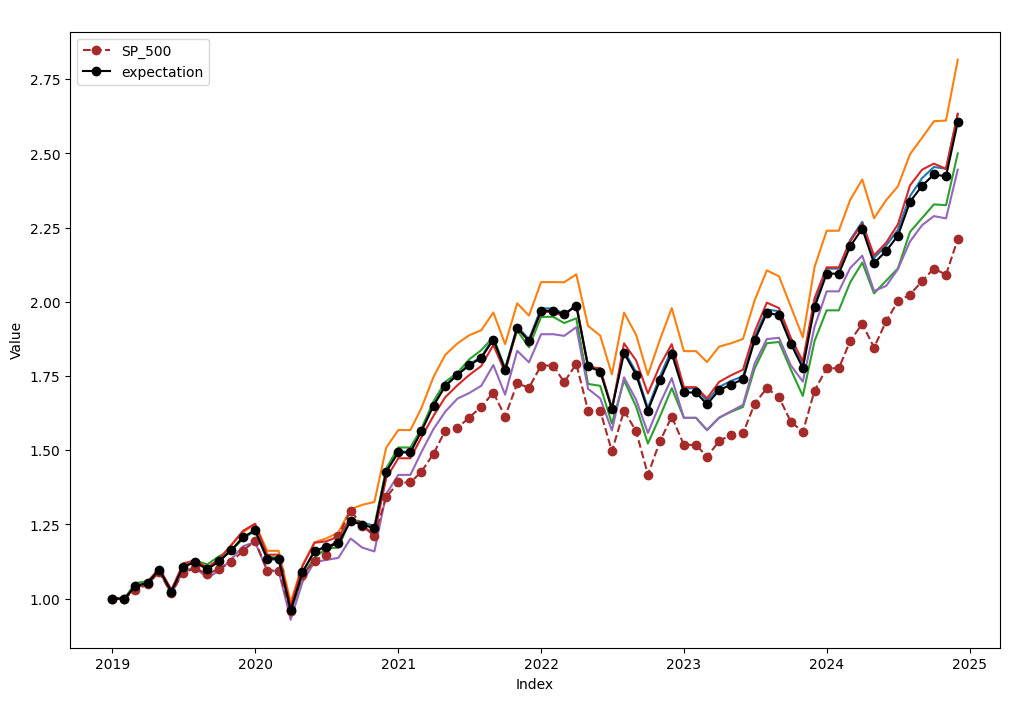

In [59]:
avg_100=final_visual()
oos1_list[0] = avg_100.copy()
fill_rows(oos1_list)

In [65]:
performance_metrics(oos1_list[0],0.0312)

,Cumulative Return,Annualized Return,Observed Volatility,Downside Volatility,Sharpe,Sortino
Ticker,,,,,,
SP_500,0.755551,0.123488,0.180028,0.117747,0.567847,0.868204
Optimized Portfolio,0.387595,0.070123,0.207067,0.137826,0.281619,0.423097


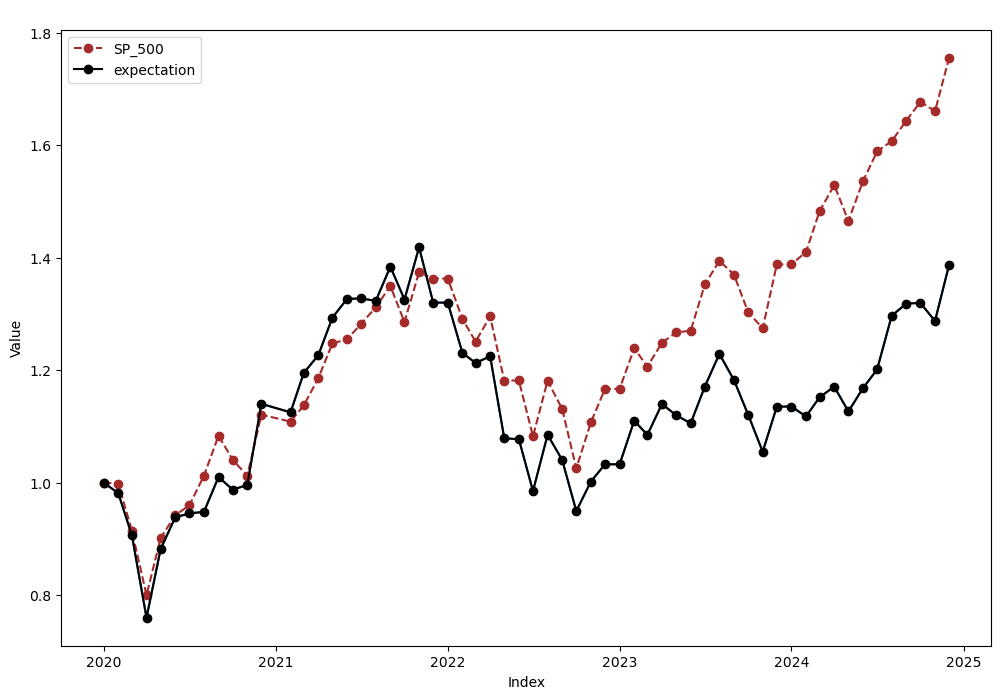

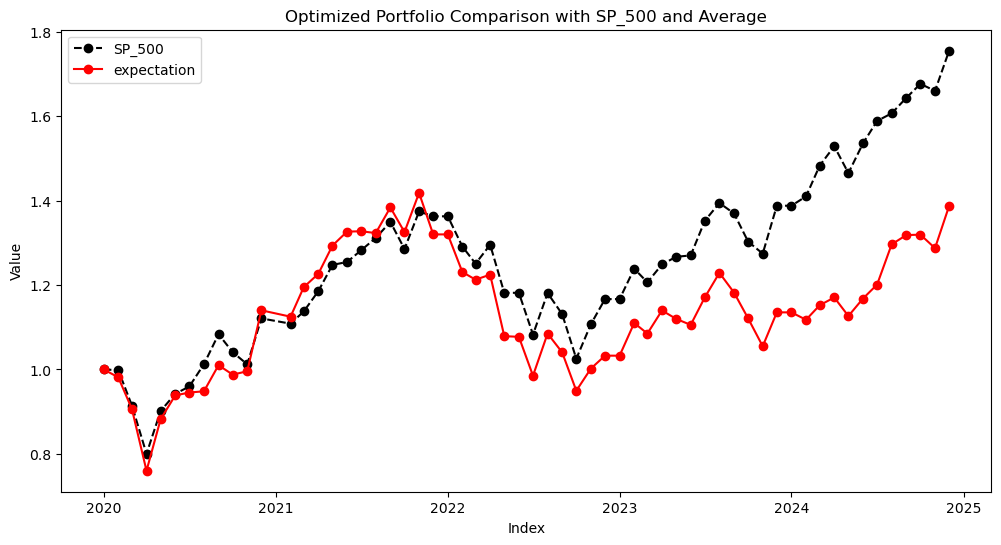

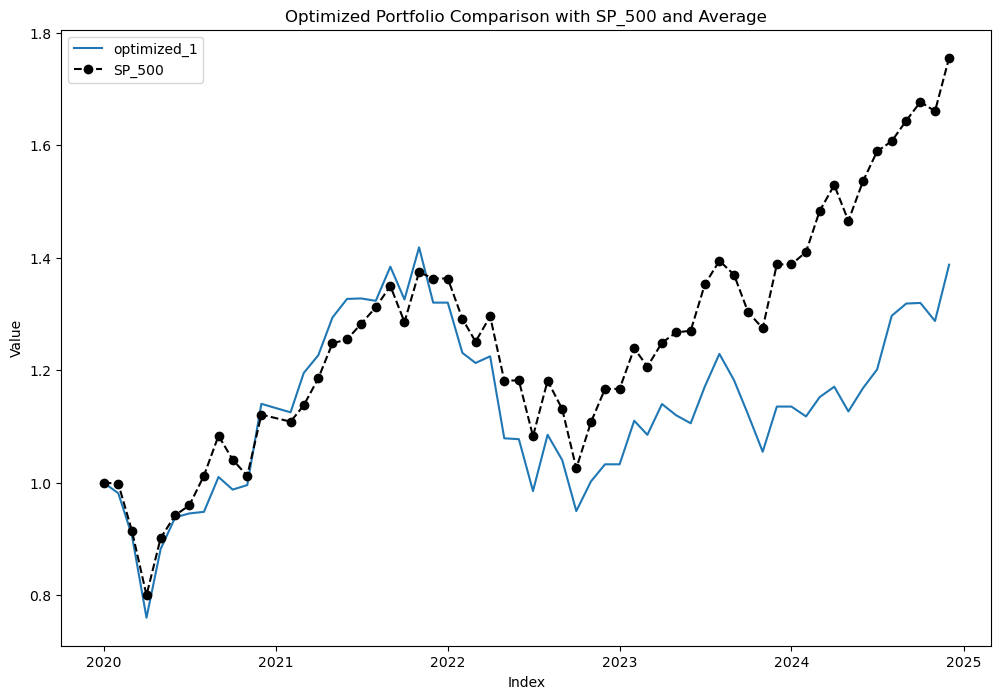

,SP_500,Optimized Portfolio
Date,,
2020-01-01,1.000000,1.000000
2020-02-01,0.998372,0.981348
2020-03-01,0.914399,0.906224
2020-04-01,0.799990,0.759899
2020-05-01,0.901464,0.882008
2020-06-01,0.942284,0.938406
2020-07-01,0.959611,0.945319
2020-08-01,1.012487,0.948163
2020-09-01,1.083426,1.010081


In [64]:
avg_100=final_visual()#100
final_visual2()
final_visual1()
avg_100

In [ ]:
# MULTI RUN VOLATILITY GRAPH

vol_df = pd.DataFrame(columns=['Volatility'])
for i in range(1, 6):
    if i == 1:
        oos1_list,oos1_list_yearly,oos1_average = monte_carlo_simulation(1,1,0.7,0.7,'rebalance',3,5, pd.to_datetime('2015-01-01'))
        rebalanced_optimal_weights()
        vol = calculate_volatility(rebalance_optimal_weights_appended)
        vol_df['1|.7|.7']= vol['Monthly Volatility']
    if i == 2:
        oos1_list,oos1_list_yearly,oos1_average = monte_carlo_simulation(1,1,1,0.1,'rebalance',3,5, pd.to_datetime('2015-01-01'))
        rebalanced_optimal_weights()
        vol = calculate_volatility(rebalance_optimal_weights_appended)
        vol_df['1|1|.1']= vol['Monthly Volatility']
        display(vol_df)
    if i == 3:
        oos1_list,oos1_list_yearly,oos1_average = monte_carlo_simulation(1,1,0.8,0.2,'rebalance',3,5,pd.to_datetime('2015-01-01'))
        rebalanced_optimal_weights()
        vol = calculate_volatility(rebalance_optimal_weights_appended)
        vol_df['1|.8|.2']= vol['Monthly Volatility']
    if i == 4:
        oos1_list,oos1_list_yearly,oos1_average = monte_carlo_simulation(1,1,1,0.3,'rebalance',3,5, pd.to_datetime('2015-01-01'))
        rebalanced_optimal_weights()
        vol = calculate_volatility(rebalance_optimal_weights_appended)
        vol_df['1|1|.3']= vol['Monthly Volatility']
    if i == 5:
        oos1_list,oos1_list_yearly,oos1_average = monte_carlo_simulation(1,1,0,0,'rebalance',3,5, pd.to_datetime('2015-01-01'))
        rebalanced_optimal_weights()
        vol = calculate_volatility(rebalance_optimal_weights_appended)
        vol_df['1|0|0']= vol['Monthly Volatility']
fig, ax = plt.subplots(figsize=(12, 6))

# Store line handles to later extract colors
line_handles = []

# Plot each portfolio's volatility and store the line handle
for col in vol_df.columns:
    line, = ax.plot(vol_df.index, vol_df[col], label=col, marker='o', markersize=8, markevery=12)
    line_handles.append((col, line))

# Now plot the mean line using the same color as each line
for col, line in line_handles:
    mean_val = vol_df[col].mean()
    ax.axhline(mean_val, linestyle='--', alpha=0.7, color=line.get_color(), label=f'{col} Mean')

# Plot SPY and its mean line
spy_line, = ax.plot(spy_v.index, spy_v['DATE SPY_V'], label='SP_500', color='black', marker='o', markersize=8, markevery=12)
spy_mean = spy_v['DATE SPY_V'].mean()
ax.axhline(spy_mean, color=spy_line.get_color(), linestyle='--', alpha=0.7, label='SP_500 Mean')

# Labels and formatting
ax.set_xlabel('MoM', fontsize=14)
ax.set_ylabel('Volatility', fontsize=14)
ax.set_title('Realized Volatility of Optimal Portfolio vs SPY', fontsize=16)
ax.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [64]:
oos1_list[0] = avg_100
fill_rows(oos1_list)
oos1_list[0].style.set_sticky()

,SP_500,Optimized Portfolio
Date,,
2019-01-01 00:00:00,1.000000,1.000000
2019-02-01 00:00:00,1.000000,1.000000
2019-03-01 00:00:00,1.029729,1.042138
2019-04-01 00:00:00,1.048186,1.060969
2019-05-01 00:00:00,1.089393,1.101999
2019-06-01 00:00:00,1.017735,1.036466
2019-07-01 00:00:00,1.087888,1.113935
2019-08-01 00:00:00,1.102169,1.135950
2019-09-01 00:00:00,1.082229,1.124112


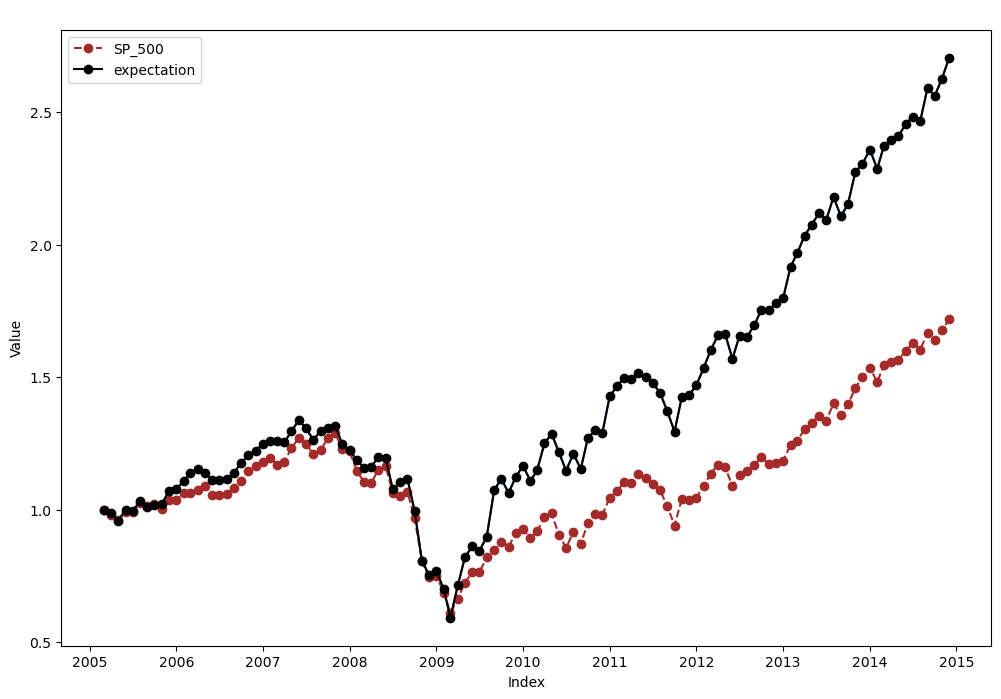

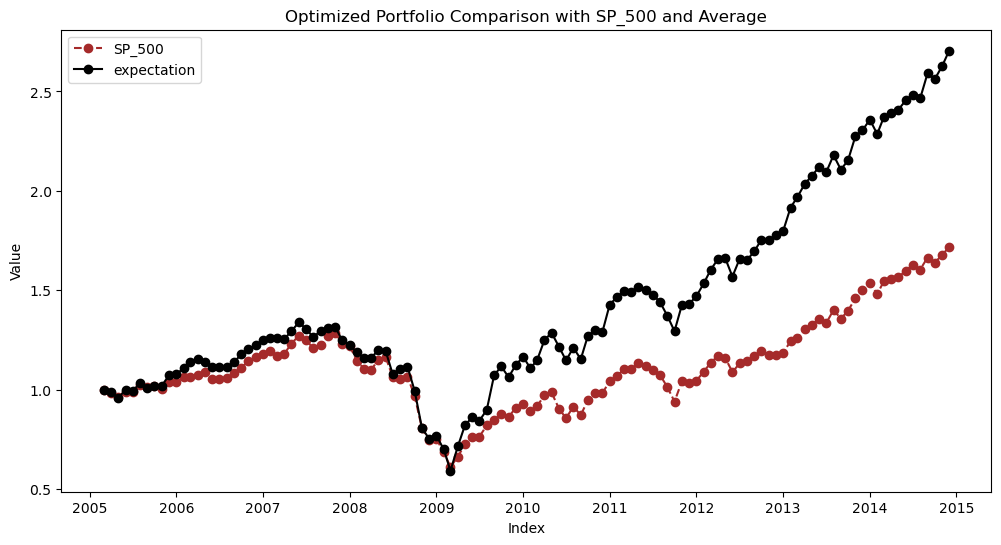

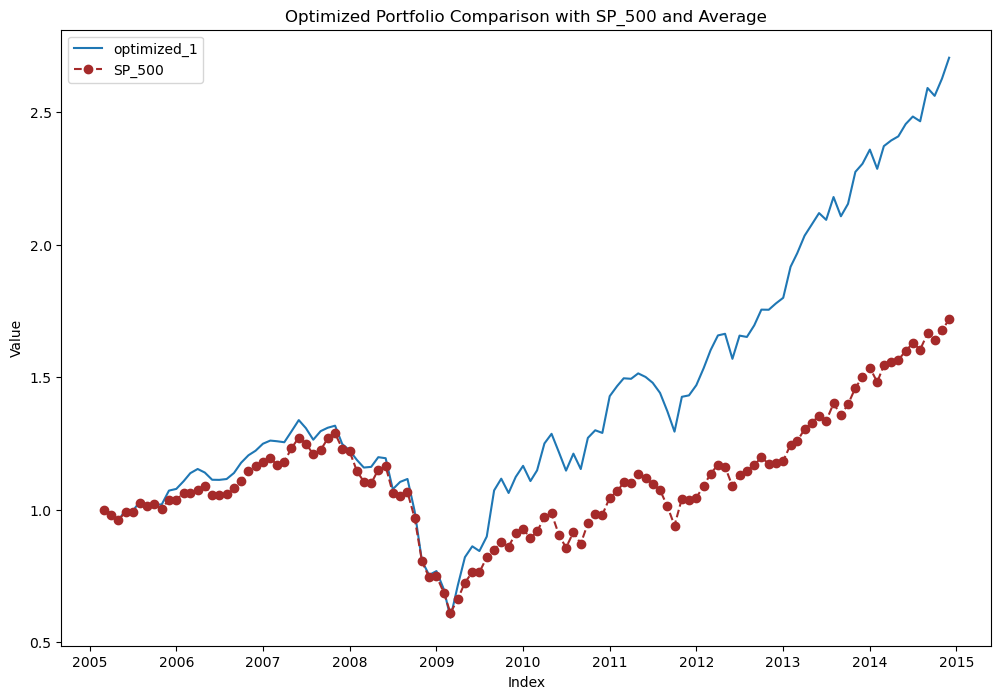

,SP_500,Optimized Portfolio
Date,,
2005-03-01,1.000000,1.000000
2005-04-01,0.980882,0.987465
2005-05-01,0.961157,0.958776
2005-06-01,0.989946,0.998192
2005-07-01,0.989804,0.993781
...,...,...
2014-08-01,1.604088,2.464957
2014-09-01,1.664490,2.590523
2014-10-01,1.638667,2.560831


In [187]:
avg_100=final_visual()#100
final_visual2()
final_visual1()
avg_100

In [205]:
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,1,0,0,'rebalance')
avg_100=final_visual()#100
final_visual2()
final_visual1()
avg_100

TypeError: monte_carlo_simulation() missing 3 required positional arguments: 'in_years1', 'out_years', and 'stop'

In [88]:
oos1_list[0].style.set_sticky()

Ticker,SP_500,Optimized Portfolio
Date,,
2019-01-01 00:00:00,1.000000,1.000000
2019-02-01 00:00:00,1.000000,1.000000
2019-03-01 00:00:00,1.029729,1.039979
2019-04-01 00:00:00,1.048186,1.051253
2019-05-01 00:00:00,1.089393,1.099451
2019-06-01 00:00:00,1.017735,1.036701
2019-07-01 00:00:00,1.087888,1.108555
2019-08-01 00:00:00,1.102169,1.127207
2019-09-01 00:00:00,1.082229,1.104133


In [318]:
oos1_list[0]

Ticker,SP_500,Optimized Portfolio
Date,,
2005-03-01,1.000000,1.000000
2005-04-01,0.980882,0.985478
2005-05-01,0.961157,0.961890
2005-06-01,0.989946,1.004423
2005-07-01,0.989804,1.008349
...,...,...
2010-08-01,0.915258,1.309391
2010-09-01,0.871830,1.253527
2010-10-01,0.948160,1.382665


In [102]:
flist={}
cumulative_exp_return,yoy_exp_return,sim_one_percentile=cumulative_returns_cal(oos1_list)
sortino_simulation,sortino_list_sim,sortino_spy=list_sortino_ratio(oos1_list)
print(f'The sortino ratio of the portfolio on average:{sortino_simulation}')
print(f'The sortino ratio of the sp500 : {sortino_spy}')
print(cumulative_exp_return)
print(sim_one_percentile)

The sortino ratio of the portfolio on average:0    1.072455
dtype: float64
The sortino ratio of the sp500 : 0.8515965641269176
Year               2016       2017       2018       2019       2020  \
Percentile                                                            
99 percentile  6.250930  30.907275  66.894860  54.480559  93.446551   
Average             NaN  26.903591  61.986015  47.158004  82.238271   
1 percentile   1.363657  24.973990  58.303357  43.671778  76.707011   
sp500          2.453629  18.220512  38.698386  23.130016  47.111950   

Year                 2021        2022        2023        2024  
Percentile                                                     
99 percentile  138.136814  206.466185  170.187616  231.549395  
Average        118.125439  187.322835  159.648006  210.781523  
1 percentile   104.301405  168.533292  144.866064  186.358984  
sp500           71.309719  119.827689   86.915668  118.701034  
      1 percentile return in %
Year                          


In [ ]:
flist={}
cumulative_exp_return,yoy_exp_return,sim_one_percentile=cumulative_returns_cal(oos1_list)
sharpe_simulation,sharpe_list_sim,sharpe_spy=list_sharpe_ratio(oos1_list)
print(f'The sharpe ratio of the portfolio on average:{sharpe_simulation}')
print(f'The sharpe ratio of the sp500 : {sharpe_spy}')
print(cumulative_exp_return)
print(sim_one_percentile)
flist['100 rebalance']=avg_100
yoy_exp_return

The sharpe ratio of the portfolio on average:0    0.810157
dtype: float64
The sharpe ratio of the sp500 : 0.6342081308997127
Year               2016       2017       2018       2019       2020  \
Percentile                                                            
99 percentile  6.250930  30.907275  66.894860  54.480559  93.446551   
Average             NaN  26.903591  61.986015  47.158004  82.238271   
1 percentile   1.363657  24.973990  58.303357  43.671778  76.707011   
sp500          2.453629  18.220512  38.698386  23.130016  47.111950   

Year                 2021        2022        2023        2024  
Percentile                                                     
99 percentile  138.136814  206.466185  170.187616  231.549395  
Average        118.125439  187.322835  159.648006  210.781523  
1 percentile   104.301405  168.533292  144.866064  186.358984  
sp500           71.309719  119.827689   86.915668  118.701034  
      1 percentile return in %
Year                          
1 

FileNotFoundError: [Errno 2] No such file or directory: 'combination_data.xlsx'

'2020-11-29'

In [ ]:
sharpe_simulation,sharpe_list_sim,sharpe_spy=list_sharpe_ratio(oos1_list)
print(f'The sharpe ratio of the portfolio on average:{sharpe_simulation}')
print(f'The sharpe ratio of the sp500 : {sharpe_spy}')

In [ ]:
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,1,0,0,'no')



Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
True
Column 'TPL' could not be converted to float.
Column 'TPL' could not be converted to float.


'2019-12-01'

'2024-11-29'

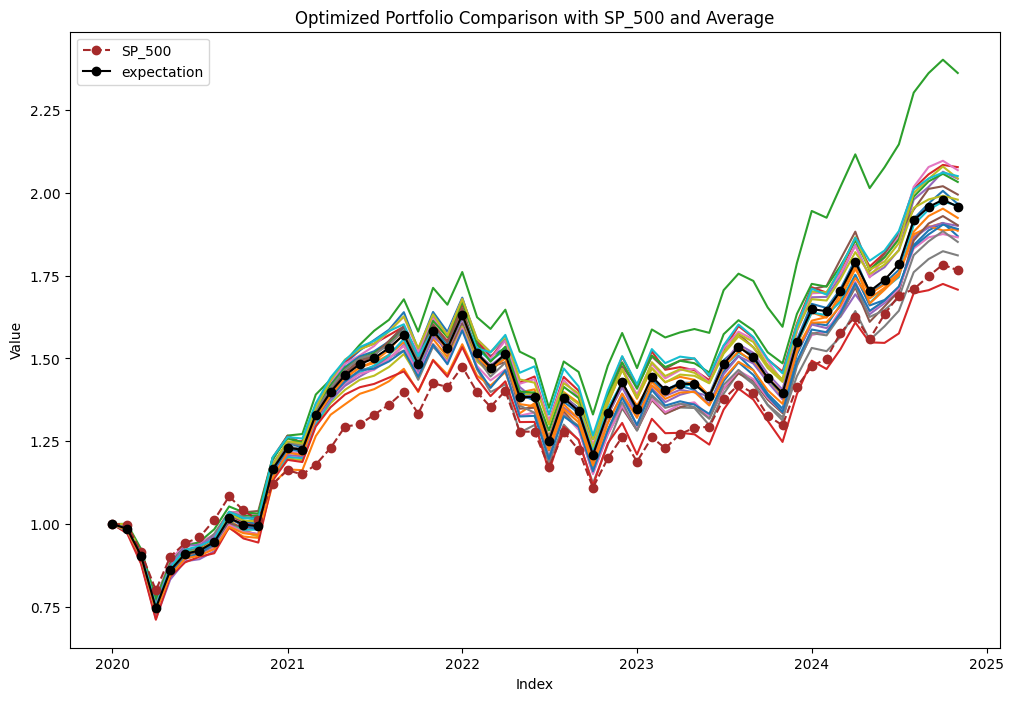

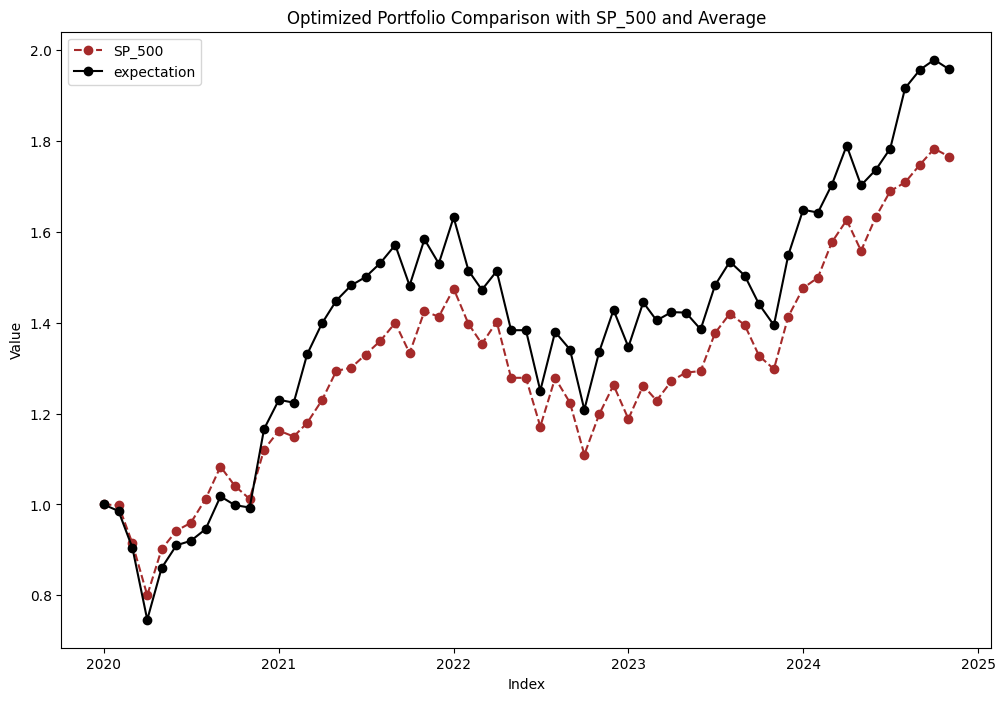

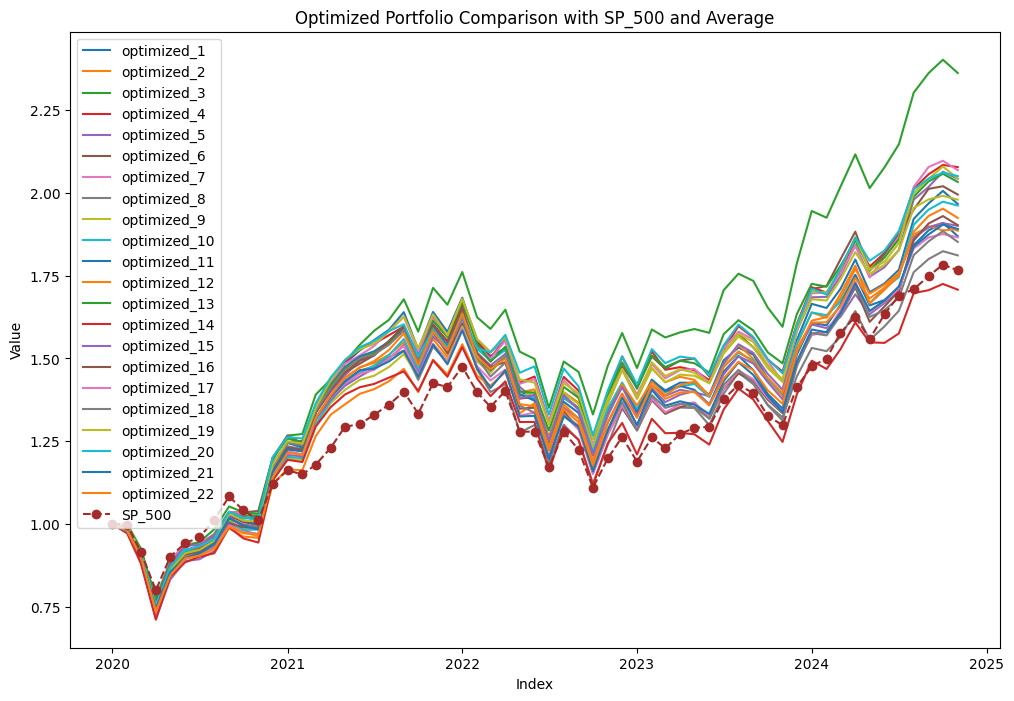

,SP_500,Optimized Portfolio
Date,,
2020-01-01,1.000000,1.000000
2020-02-01,0.998372,0.985658
2020-03-01,0.914399,0.904639
2020-04-01,0.799990,0.746263
2020-05-01,0.901464,0.860109
2020-06-01,0.942284,0.910232
2020-07-01,0.959611,0.919960
2020-08-01,1.012487,0.945848
2020-09-01,1.083426,1.017801


conds)
Cbc0010I After 221000 nodes, 12200 on tree, 0.016092726 best solution, best possible 0 (56788.98 seconds)
Cbc0010I After 222000 nodes, 12376 on tree, 0.016092726 best solution, best possible 0 (57160.59 seconds)
Cbc0010I After 223000 nodes, 12456 on tree, 0.016092726 best solution, best possible 0 (57913.58 seconds)
Cbc0010I After 224000 nodes, 12520 on tree, 0.016092726 best solution, best possible 0 (58831.67 seconds)
Cbc0010I After 225000 nodes, 12524 on tree, 0.016092726 best solution, best possible 0 (60194.84 seconds)
Cbc0010I After 226000 nodes, 12586 on tree, 0.016092726 best solution, best possible 0 (61411.45 seconds)
Cbc0010I After 227000 nodes, 12700 on tree, 0.016092726 best solution, best possible 0 (61771.49 seconds)
Cbc0010I After 228000 nodes, 12740 on tree, 0.016092726 best solution, best possible 0 (61901.44 seconds)
Cbc0010I After 229000 nodes, 12766 on tree, 0.016092726 best solution, best possible 0 (62103.51 seconds)
Cbc0010I After 230000 nodes, 12862 on t

In [ ]:
avg_100=final_visual()#100
final_visual2()
final_visual1()
avg_100


In [69]:

cumulative_exp_return,yoy_exp_return,sim_one_percentile=cumulative_returns_cal(oos1_list)
sharpe_simulation,sharpe_list_sim,sharpe_spy=list_sharpe_ratio(oos1_list)
print(f'The sharpe ratio of the portfolio on average:{sharpe_simulation}')
print(f'The sharpe ratio of the sp500 : {sharpe_spy}')
print(cumulative_exp_return)
print(sim_one_percentile)
save_df_with_combination_to_excel(sim_one_percentile,'combination_data.xlsx','downside_protection',[1,0,0],11,0,0)
flist['100']=avg_100
yoy_exp_return

KeyError: Timestamp('2016-02-01 00:00:00')

In [ ]:
sharpe_simulation,sharpe_list_sim,sharpe_spy=list_sharpe_ratio(oos1_list)
print(f'The sharpe ratio of the portfolio on average:{sharpe_simulation}')
print(f'The sharpe ratio of the sp500 : {sharpe_spy}')


The sharpe ratio of the portfolio on average:0    0.62092
dtype: float64
The sharpe ratio of the sp500 : 0.5962031559179566


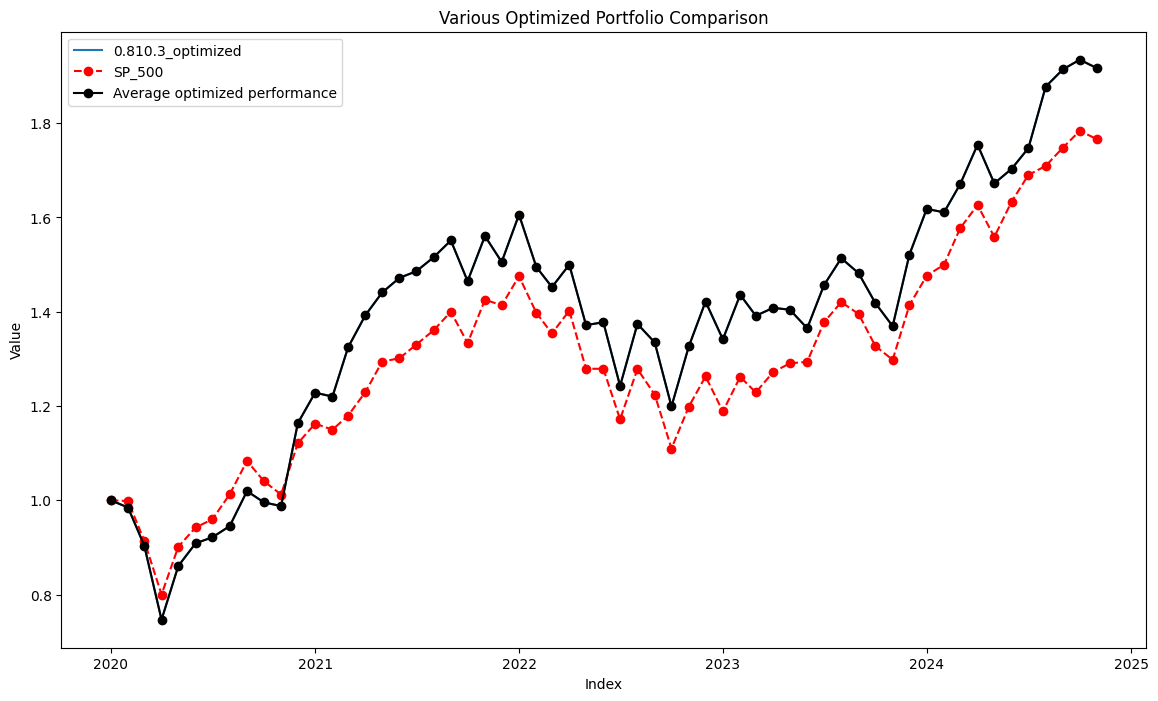

In [ ]:
finale_visual(flist)

# Saving analysis to excel sheet

In [ ]:
from openpyxl import Workbook
workbook_filename = 'combination_data.xlsx'
wb = Workbook()
wb.save(workbook_filename)


In [ ]:
save_df_with_combination_to_excel(sim_one_percentile,workbook_filename,'downside_protection',[1,0.75,0.5],0,0,0)

(1,)

In [ ]:
save_df_with_combination_to_excel(gdsk,workbook_filename,'downside_protection',['SP500','SP500','SP500'],1,0,0)

(2,)

In [ ]:
save_df_with_combination_to_excel(sim_one_percentile,workbook_filename,'downside_protection',[1,0.5,0.5],2,0,0)

(3,)

# Error checking area

In [ ]:
simulator(1,0,0,n_year_before,out_of_sample_year_end[2],upatebudget,50)
sjijas=out_of_sampless(out_of_sample_year_start[3],out_of_sample_year_end[3])
tostorelist.append(sjijas)
upatebudget=sjijas['Optimized Portfolio'][-1]*1000000




Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
Column 'TPL' could not be converted to float.
True


KeyboardInterrupt: 

In [ ]:
upatebudget=sjijas['Optimized Portfolio'][-1]*1000000

In [ ]:
simulator(1,0,0,n_year_before,n_year_after,1000000,50)
sjijas=out_of_sampless(out_of_sample_year_start[1],out_of_sample_year_end[1])
tostorelist.append(sjijas)
upatebudget=sjijas['Optimized Portfolio'][-1]*1000000




Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
True
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/d158aa235171444682b203a5a0404b18-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/d158aa235171444682b203a5a0404b18-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2316 COLUMNS
At line 41761 RHS
At line 44073 BOUNDS
At line 44521 ENDATA
Problem MODEL has 2311 rows, 2271 columns and 38514 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.07 seconds
Cgl0004I processed model has 968 rows, 1374 columns (446 integer (446 of which binary)) and 35752 elements
Cbc0038I Initial

In [ ]:
upatebudget

1272053.7273467889

In [ ]:
out_of_sample_year_end[2]

'2021-12-01'

### FUTURE SIMULATOR & VOLATILITY

In [66]:
rebalance_optimal_weights_appended.style.set_sticky()

NameError: name 'rebalance_optimal_weights_appended' is not defined

NameError: name 'monthly_data1' is not defined

In [ ]:
def to__cal_stock_betas_monthly(i, start111, opt_weights_appended):
    
    if(len(opt_weights_appended) > 1):  
        list = opt_weights_appended.iloc[i]
    else:
        list = opt_weights_appended.iloc[0]
        
    list = list[list !=0]
    
    start111 = start111 - relativedelta(years=3)
    end111 = start111 + relativedelta(months=35)
    rolling_rebal = extract_stock_data(new_monthly_data, list.index, start111, end111)
    rebal_betas = pd.DataFrame()
    # Iterate over the tickers list
    for col in rolling_rebal.columns:
        # Set the dependent variable (Return of stock i)
        y = rolling_rebal[col]
        # Set the independent variables (Fama French 3 Factors)
        X = (ff3_monthly_FS[['Mkt-RF','SMB','HML']].loc[start111:end111])
        # Fit the multiple linear regression model
        model = LinearRegression()
        model.fit(X, y)
        # Store the results in the DataFrame
        rebal_betas[col] = [model.intercept_] + model.coef_.tolist()
    rebal_betas = rebal_betas.T
    rebal_betas.columns = ['Intercept','Mkt-RF','SMB','HML']
    ff3_factors = rebal_betas.mul(list, axis=0).sum()
    ff3_factors = ff3_factors.iloc[1:]
    
    return ff3_factors 

In [68]:
def rebalanced_optimal_weights():
    global rebalance_optimal_weights_appended
    output_years = oos1_list[0].index.year.unique().tolist()
    dfs = []
    rebalance_optimal_weights_appended = pd.DataFrame()
    
    for i, df_year in enumerate(rebalance_opt_weights[:len(output_years)]):
        df_temp = df_year.copy()
        df_temp.columns = [output_years[i]]  # Assign column names based on output years
        dfs.append(df_temp)

    df_final = pd.concat(dfs, axis=1).fillna(0)
    df_final.index = df_final.index.str[7:]
    df_final = df_final.T

    for i, year in enumerate(output_years):
        temp_df = optimal_weights_appended(pd.DataFrame(df_final.iloc[i]))   # type: ignore
        temp_df = temp_df.loc[temp_df.index.year == year]  # Filter by the current year
        rebalance_optimal_weights_appended = pd.concat([rebalance_optimal_weights_appended, temp_df])



In [69]:
def optimal_weights_appended(opt_port):  
    
    tickers_opt = opt_port.index.tolist()
    prices = pd.read_csv('daat.csv', parse_dates=['date'])
    prices.drop(columns='PERMNO', inplace=True)
    prices.drop(columns='RET', inplace=True)
    prices.rename(columns={'date': 'Date', 'TICKER': 'Ticker'}, inplace=True)
    prices.set_index('Date', inplace=True)
    prices.index = pd.to_datetime(prices.index)
    prices = prices.pivot_table(index='Date', columns='Ticker', values='PRC', aggfunc='first')
    prices = extract_stock_data(prices, opt_port.index.tolist(), start_date, end_date)
    
    # if value is NA, averages it with the before and after, as it would be too difficult to manually enter it if we scale up the use of this
    prices = prices.interpolate(method = 'linear', limit_direction = 'both') 
    base_prices = prices.iloc[0]
    holding_values = pd.DataFrame(index=prices.index, columns=prices.columns)
    for tickers_opt in prices.columns:
        weight_opt = opt_port.loc[tickers_opt].iloc[0]
        # (price / price_base) * initial_weight.
        holding_values[tickers_opt] = (prices[tickers_opt] / base_prices[tickers_opt]) * weight_opt

    # calc total portfolio value for each month.
    portfolio_value = holding_values.sum(axis=1)
    
    # normalize the values
    opt_portfolio_weights_appended = holding_values.div(portfolio_value, axis=0)
    return opt_portfolio_weights_appended

In [70]:
def optimal_future_weights(futures_df, date):
    
    prices = pd.read_csv('daat.csv', parse_dates=['date'])
    prices.drop(columns=['PERMNO', 'RET'], inplace=True)
    prices.rename(columns={'date': 'Date', 'TICKER': 'Ticker'}, inplace=True)
    prices.set_index('Date', inplace=True)
    prices.index = pd.to_datetime(prices.index)
    prices = prices.pivot_table(index='Date', columns='Ticker', values='PRC', aggfunc='first')
    prices = extract_stock_data(prices, futures_df.index.tolist(), start_date, end_date)
    
    base_prices = prices.loc[date]
    initial_weights = futures_df.iloc[:, 0]
    holding_values = pd.DataFrame(index=prices.index, columns=prices.columns)
    for ticker in prices.columns:
        weight = initial_weights[ticker]
        holding_values[ticker] = (prices[ticker] / base_prices[ticker]) * weight
    
    # Return the holding values without any normalization.
    return holding_values


In [71]:

def monthly_beta_change(i, futures_df, date, total_portf_future_weights):
    # so you input the index you start at first (i) and it returns a data frame of each te difference of each 3 factors for the next month 
    # this approach makes it so you can add the options to be considered into the ff3 differnces to compare and use w/o figures
    opt_portf_index = rebalance_optimal_weights_appended.copy()
    futures_df_adjusted = optimal_future_weights(futures_df, date)
    opt_portf_weights_appended = pd.concat([opt_portf_index, futures_df_adjusted], axis=1)
    row_normalized = opt_portf_weights_appended.abs().sum(axis=1)
    opt_portf_weights_appended = opt_portf_weights_appended.div(row_normalized, axis=0)
    row = opt_portf_weights_appended.loc[[date]]
    total_portf_future_weights = pd.concat([total_portf_future_weights, row], axis = 0)
    ff3_df_end = to__cal_stock_betas_monthly(i, oos1_list[0].index[i], opt_portf_weights_appended)   

    return ff3_df_end, total_portf_future_weights

In [72]:
def get_fama_by_q():
    ff3_quarters = gff.famaFrench3Factor(frequency='m')
    ff3_quarters.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
    ff3_quarters['Date'] = pd.to_datetime(ff3_quarters['Date'])
    ff3_quarters.set_index('Date', inplace=True)
    ff3_quarters.sort_index(inplace=True)
    ff3_quarterly = ff3_quarters.resample('Q').mean()

    # Resample the quarterly data to monthly frequency by forward-filling
    return ff3_quarters.loc[oos1_new_performance.index]

# Ill keep this incase we want to hedge by quarters, as this works as a base case for ff3 regression


In [73]:
# similar to hedge_portoflio_function, jsut written for all 3 factros and specific indexes
def calculate_futures_positions(current_betas, optimal_betas, portfolio_value, futures_prices, EOM_futures_prices, default_contract_multipliers, desired_notional_exposures, dynamic_tickers, i):
    
    # compute beta differences for each factor:
    delta_MKT = (optimal_betas['Mkt-RF'] - current_betas['Mkt-RF'])
    delta_SMB = (optimal_betas['SMB'] - current_betas['SMB'])
    delta_HML = (optimal_betas['HML'] - current_betas['HML'])
    
    positions = []
    scale_factor = 1 # to multiply by 10 for index multiple, its faster... 
    def get_multiplier(ticker):
        return default_contract_multipliers[ticker] 

    # Market factor: ES=F
    pos_MKT = "LONG" if delta_MKT > 0 else ("SHORT" if delta_MKT < 0 else "NO ACTION")
    mult_MKT = get_multiplier("SPY")
    if mult_MKT > 0:
        contracts_MKT = ((desired_notional_exposures.loc["SPY"] * portfolio_value) / (mult_MKT * futures_prices.loc["SPY"])).iloc[0][0]
    else:
        contracts_MKT = 0
    if round(contracts_MKT,0)== 0:
        pos_MKT = "NO ACTION"
    positions.append({
        "ETF Name": "SPY",
        "Position": pos_MKT,
        "Number of Contracts": round(contracts_MKT, 0),
        "Cost of Contracts ($)": round(futures_prices.loc["SPY"] *round(contracts_MKT, 0),2)/scale_factor,
        "EOM Value ($)": round(EOM_futures_prices.loc["SPY"].iloc[0] *round(contracts_MKT, 0),2)/scale_factor,
        "Multiplier": round(mult_MKT,2)
    })
    
    # SMB factor:
    # IWM (small-cap) follows the sign of delta_SMB.
    pos_IWM = "LONG" if delta_SMB > 0 else ("SHORT" if delta_SMB < 0 else "NO ACTION")
    mult_IWM = get_multiplier("IWM")
    if mult_IWM > 0:
        contracts_IWM = ((desired_notional_exposures.loc["IWM"] * portfolio_value) / (mult_IWM*(futures_prices.loc["IWM"]))).iloc[0][0]
    else:
        contracts_IWM = 0
    if round(contracts_IWM,0)  == 0:
        pos_IWM = "NO ACTION"
        
    positions.append({
        "ETF Name": "IWM",
        "Position": pos_IWM,
        "Number of Contracts": round(contracts_IWM, 0),
        "Cost of Contracts ($)": round(futures_prices.loc["IWM"]*round(contracts_IWM, 0),2)/scale_factor,
        "EOM Value ($)": round(EOM_futures_prices.loc["IWM"].iloc[0] *round(contracts_IWM, 0),2)/scale_factor,
        "Multiplier": mult_IWM
    })
    
    # IWB (large-cap) takes the opposite signal of delta_SMB.
    pos_IWB = "SHORT" if delta_SMB > 0 else ("LONG" if delta_SMB < 0 else "NO ACTION")
    mult_IWB = get_multiplier("IWB")
    if mult_IWB > 0:
        contracts_IWB = ((desired_notional_exposures.loc["IWB"] * portfolio_value) / (mult_IWB*(futures_prices.loc["IWB"]))).iloc[0][0]
    else:
        contracts_IWB = 0
    if round(contracts_IWB,0)  == 0:
        pos_IWB = "NO ACTION"
        
    positions.append({
        "ETF Name": "IWB",
        "Position": pos_IWB,
        "Number of Contracts": round(contracts_IWB, 0),
        "Cost of Contracts ($)": round(futures_prices.loc["IWB"]*round(contracts_IWB, 0),2)/scale_factor,
        "EOM Value ($)": round(EOM_futures_prices.loc["IWB"].iloc[0]*round(contracts_IWB, 0),2)/scale_factor,
        "Multiplier": mult_IWB
    })
    
    # HML factor:
    # IWD (value) follows the sign of delta_HML.
    pos_IWD = "LONG" if delta_HML > 0 else ("SHORT" if delta_HML < 0 else "NO ACTION")
    mult_IWD = get_multiplier("IWD")
    if mult_IWD > 0:
        contracts_IWD = ((desired_notional_exposures.loc["IWD"] * portfolio_value) / (mult_IWD*(futures_prices.loc["IWD"]))).iloc[0][0]
    else:
        contracts_IWD = 0
    if round(contracts_IWD,0)  == 0:
        pos_IWD = "NO ACTION"
        
    positions.append({
        "ETF Name": "IWD",
        "Position": pos_IWD,
        "Number of Contracts": round(contracts_IWD, 0),
        "Cost of Contracts ($)": round(futures_prices.loc["IWD"] *round(contracts_IWD, 0), 2)/scale_factor,
        "EOM Value ($)": round(EOM_futures_prices.loc["IWD"].iloc[0] *round(contracts_IWD, 0), 2)/scale_factor,
        "Multiplier": mult_IWD
         })
    
    # IWF (growth) takes the opposite signal of delta_HML.
    pos_IWF = "SHORT" if delta_HML > 0 else ("LONG" if delta_HML < 0 else "NO ACTION")
    mult_IWF = get_multiplier("IWF")
    if mult_IWF > 0:
        contracts_IWF = ((desired_notional_exposures.loc["IWF"] * portfolio_value) / (mult_IWF*(futures_prices.loc["IWF"]))).iloc[0][0]
    else:
        contracts_IWF = 0
    if round(contracts_IWF,0)  == 0:
        pos_IWF = "NO ACTION"
        
    positions.append({
        "ETF Name": "IWF",
        "Position": pos_IWF,
        "Number of Contracts": round(contracts_IWF, 0),
        "Cost of Contracts ($)": round(futures_prices.loc["IWF"] *round(contracts_IWF, 0), 2)/scale_factor,
        "EOM Value ($)": round(EOM_futures_prices.loc["IWF"].iloc[0]*round(contracts_IWF, 0),2)/scale_factor,
        "Multiplier": mult_IWF
    })

    return pd.DataFrame(positions, columns=["ETF Name", "Position", "Number of Contracts", "Cost of Contracts ($)", "EOM Value ($)"]) 
    

In [74]:
def compute_optimal_exposure(betas_difference, returns, start_1, i):
    # Step 1: Define C
    C = pd.DataFrame()
    for etf in returns.index:
        b1 = to__cal_stock_betas_monthly(i,start_1, pd.DataFrame(data = 1.0, columns = [etf], index = [start_1]))
        b1.name = etf   
        C = pd.concat([C, b1], axis = 1)
    # Step 2: Solve for w = arg min||C - b||^2, minimizes the squared difference of preivous defined vector and the beta difference
    w, residuals, rank, s = np.linalg.lstsq(C, betas_difference, rcond = None)
    w = pd.DataFrame({'Exposure': np.array(w)}, index = [returns.index])
    return w.abs()


In [75]:
# need function to calculate p/l of the hedging 
def calc_hedging_pl(hedge_df):

    # computes the change in value, profit if stocks goes up and is LONG, and loss if stock goes up and is SHORT - vice versa 
    hedge_df["P/L ($)"] = hedge_df.apply(
        lambda row: (row["EOM Value ($)"] - row["Cost of Contracts ($)"])
        if row["Position"] == "LONG" else
        (row["Cost of Contracts ($)"] - row["EOM Value ($)"]),
        axis=1
    )

    # computes +- change relative to total value of futures, because the amounts are not constant 
    total_cost = hedge_df["Cost of Contracts ($)"].sum()
    hedge_df["P/L (%)"] = hedge_df.apply(
        lambda row: (row["P/L ($)"] / total_cost * 100)
        if row["Cost of Contracts ($)"] != 0 else 0,
        axis=1
    )

    hedge_df["P/L ($)"] = hedge_df["P/L ($)"].round(2)
    hedge_df["P/L (%)"] = hedge_df["P/L (%)"].round(2)
    
    return hedge_df

In [ ]:
def famafrenchreturns_FS():
    global ff3_monthly_FS
    # Fama French Monthly Returns Data using getFamaFrenchFactors 
    ff3_monthly_FS = gff.famaFrench3Factor(frequency='m')
    ff3_monthly_FS.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
    ff3_monthly_FS.set_index('Date', inplace=True)
    ff3_monthly_FS.index = ff3_monthly_FS.index.to_period('M').to_timestamp('D')
    # Keeping Only the Dates in the monthly_data

    dates = oos1_list[0].index
    dates_minus_3_years = pd.DatetimeIndex([d - relativedelta(years=3) for d in dates])
    combined_dates_index = dates.append(dates_minus_3_years).sort_values()

    ff3_monthly_FS = ff3_monthly_FS.loc[combined_dates_index]
    ff3_monthly_FS = ff3_monthly_FS.groupby(level=0).last()  # or .mean(), etc.
    ff3_monthly_FS = ff3_monthly_FS.asfreq('MS')  
    ff3_monthly_FS = ff3_monthly_FS.interpolate(method='linear')



In [ ]:
# # REWRITE, MKT-RF - SMB - HML, SP_500  & RUSSELL FUTURES TO ACHIEVE OPTIMIZED HEDGING, using monthly futures for now.
from IPython.display import display

famafrenchreturns_FS()
global total_portf_future_weights
total_portf_future_weights = pd.DataFrame()
rebalanced_optimal_weights()
start1 = oos1_list[0].index[0]
end1 = oos1_list[0].index[-1]

global total_ff3_nof
global total_ff3_f
total_ff3_nof = pd.DataFrame()
total_ff3_f = pd.DataFrame()
# RETURNS

#import future data
future_data = pd.read_csv('daat.csv')
future_data.set_index('TICKER', inplace=True)
future_data=future_data[['date','PRC']]

#MKT-RF futures
MKT_RF_futures = future_data.loc['SPY']
MKT_RF_futures.set_index('date', inplace=True)

# Pre Process to average NAs with last and next month, contracts do get redownloaded, but this method is used as well-
# MKT_RF_futures = MKT_RF_futures.interpolate(method='linear', limit_direction='both')
MKT_RF_futures = MKT_RF_futures.loc[start_date:end_date]

#SMB futures- # this is subject to change
L_R2000F_small_cap = future_data.loc['IWM']
L_R2000F_small_cap.set_index('date', inplace=True)

S_R1000F_large_cap = future_data.loc['IWB']
S_R1000F_large_cap.set_index('date', inplace=True)


# Pre Process to average NAs with last and next month, contracts do get redownloaded, but this method is used as well-
# S_R1000F_large_cap = S_R1000F_large_cap.interpolate(method='linear', limit_direction='both')
s_1 = S_R1000F_large_cap.loc[start_date:end_date]

# L_R2000F_small_cap = L_R2000F_small_cap.interpolate(method='linear', limit_direction='both')
s_2 = L_R2000F_small_cap.loc[start_date:end_date]

#HML futures- # this is subject to change
L_R1000F_value = future_data.loc['IWD']
L_R1000F_value.set_index('date', inplace=True)

S_R1000F_growth = future_data.loc['IWF']
S_R1000F_growth.set_index('date', inplace=True)

# Pre Process to average NAs with last and next month, contracts do get redownloaded, but this method is used as well-
# L_R1000F_value = L_R1000F_value.interpolate(method='linear', limit_direction='both')
h_1 = L_R1000F_value.loc[start_date:end_date]

# S_R1000F_growth = S_R1000F_growth.interpolate(method='linear', limit_direction='both')
h_2 = S_R1000F_growth.loc[start_date:end_date]


# combine the 3 dfs to have a total future df
total_futures_df_prices = pd.concat([MKT_RF_futures,s_1, s_2, h_1, h_2], axis= 1).dropna()
total_futures_df_prices.columns = ['SPY', 'IWM', 'IWB', 'IWD', 'IWF']
total_futures_df_prices.index = pd.to_datetime(total_futures_df_prices.index)
total_futures_df_prices.index=total_futures_df_prices.index.to_period('M').to_timestamp('D')



# PRICES

#import future data
future_data = pd.read_csv('daat.csv')
future_data.set_index('TICKER', inplace=True)
future_data=future_data[['date','RET']]


#MKT-RF futures
MKT_RF_futures = future_data.loc['SPY']
MKT_RF_futures.set_index('date', inplace=True)

# Pre Process to average NAs with last and next month, contracts do get redownloaded, but this method is used as well-
# MKT_RF_futures = MKT_RF_futures.interpolate(method='linear', limit_direction='both')
MKT_RF_futures = MKT_RF_futures.loc[start_date:end_date]

#SMB futures- # this is subject to change
L_R2000F_small_cap = future_data.loc['IWM']
L_R2000F_small_cap.set_index('date', inplace=True)

S_R1000F_large_cap = future_data.loc['IWB']
S_R1000F_large_cap.set_index('date', inplace=True)

# Pre Process to average NAs with last and next month, contracts do get redownloaded, but this method is used as well-
# L_R2000F_small_cap = L_R2000F_small_cap.interpolate(method='linear', limit_direction='both')
s_1 = L_R2000F_small_cap.loc[start_date:end_date]

# s_1 = S_R1000F_large_cap.interpolate(method='linear', limit_direction='both')
s_2 = s_1.loc[start_date:end_date]

#HML futures- # this is subject to change
L_R1000F_value = future_data.loc['IWD']
L_R1000F_value.set_index('date', inplace=True)

S_R1000F_growth = future_data.loc['IWF']
S_R1000F_growth.set_index('date', inplace=True)

# Pre Process to average NAs with last and next month, contracts do get redownloaded, but this method is used as well-
# L_R1000F_value = L_R1000F_value.interpolate(method='linear', limit_direction='both')
h_1 = L_R1000F_value.loc[start_date:end_date]

# S_R1000F_growth = S_R1000F_growth.interpolate(method='linear', limit_direction='both')
h_2 = S_R1000F_growth.loc[start_date:end_date]


# combine the 3 dfs to have a total future df
total_futures_df_returns = pd.concat([MKT_RF_futures,s_1, s_2, h_1, h_2], axis= 1).dropna()
total_futures_df_returns.columns = ['SPY', 'IWM', 'IWB', 'IWD', 'IWF']
total_futures_df_returns.index = pd.to_datetime(total_futures_df_returns.index)
total_futures_df_returns.index=total_futures_df_returns.index.to_period('M').to_timestamp('D')

display(total_futures_df)
#leaving out the minmum variance hedge ratio, but will add it if needed- I wasnt using it in my quarter simulator


#prepares all optimal values from port_betas
#0- MKT, 1- SMB, 2-HML 
betas_target = pd.Series({'Mkt-RF': port_betas.iloc[0][1], 'SMB': port_betas.iloc[1][1], 'HML': port_betas.iloc[2][1]}) # if we want this to change and be dyanimc, we can put in the loop and change M/M

print("Target Beta Values")
display(betas_target)
total_future_pl = 0
m_future_list = []
#Simulator for 12 months:
monte_carlo_pl = []
rolling_pl = []
for x in range(0, 1):
    for i in range (0, len(oos1_list[0])-1):
        start_1 = oos1_list[0].index[i] 
        betas_current = (to__cal_stock_betas_monthly(i, start_1, rebalance_optimal_weights_appended))

        print("Size of each contract being hedged")
        print("Current Beta Values: ")
        display(betas_current)
        
        print("Difference of Beta Values: ")
        betas_difference = betas_target - betas_current
        display(betas_difference)
        
        future_returns = total_futures_df_returns.iloc[i]
        future_prices = total_futures_df_prices.iloc[i]
        future_returns = pd.DataFrame({"Prices": [future_returns.iloc[0], future_returns.iloc[1], future_returns.iloc[2],future_returns.iloc[3], future_returns.iloc[4]]}, index=["SPY", "IWM", "IWB", "IWD", "IWF"])
        EOM_future_prices = total_futures_df_prices.iloc[i+1]
        EOM_future_prices = pd.DataFrame({"Prices": [EOM_future_prices.iloc[0], EOM_future_prices.iloc[1], EOM_future_prices.iloc[2],EOM_future_prices.iloc[3], EOM_future_prices.iloc[4]]}, index=["SPY", "IWM", "IWB", "IWD", "IWF"])
        # total value of the 5 futures
        F = (future_prices.sum()).item() 
        beta_multiplier = F 
        future_w = pd.DataFrame(future_prices/ future_prices.sum())
        future_w = future_w.T
    
        nototional_exposure = compute_optimal_exposure(betas_difference, future_returns, start_1, i )
        default_contract_multipliers = { "SPY": 10, "IWM": 10, "IWB": 10, "IWD": 10, "IWF": 10} # I may try some of these constant 
        dynamic_tickers = {"SPY", "IWM", "IWB", "IWD", "IWF"} 
        print()
        
        hedge_df = calculate_futures_positions(betas_current, betas_target, (1000000 * oos1_list[0].loc[start_1].iloc[-1]), future_prices, EOM_future_prices, default_contract_multipliers, nototional_exposure, dynamic_tickers, i)
        hedge_df = hedge_df.set_index("ETF Name")
        hedge_df = calc_hedging_pl(hedge_df)
        display(hedge_df)
        total_future_pl += hedge_df['P/L ($)'].sum()
        rolling_pl.append(hedge_df['P/L ($)'].sum())
        m_future_list.append(hedge_df['P/L ($)'].sum())
        # Next part is calculating the futures difference on the ff3 betas. The startegy is adding the 5 tickers of futures to opt_portf_weights(or rebalanced using rebalance_optimal_weights_appened), with Long contracts being postive and Short negative. 
        # Pre processing/ index matching opt_portf_weights and the future weights 
        
        position_cost_df = hedge_df[["Position", "Cost of Contracts ($)"]].copy()
        position_cost_df["Cost of Contracts ($)"] = position_cost_df.apply(
            lambda row: -row["Cost of Contracts ($)"] if row["Position"] == "SHORT" else row["Cost of Contracts ($)"],
            axis=1
        )
        
        future_weights = position_cost_df.drop(columns=["Position"])
        future_weights["Cost of Contracts ($)"] = future_weights["Cost of Contracts ($)"] /  (B * oos1_list[0].loc[start_1].iloc[-1])
        
        
        future_weights.index = future_weights.index.astype(str)
        future_weights = future_weights.rename(columns={'Cost of Contracts ($)': ''})
        future_weights = future_weights.rename_axis("Ticker")
        
        ff3_df_eom_no_futures = pd.Series(to__cal_stock_betas_monthly(i+1, oos1_list[0].index[i+1], rebalance_optimal_weights_appended))
        ff3_df_eom_w_futures, total_portf_future_weights = monthly_beta_change(i+1, future_weights, oos1_list[0].index[i+1], total_portf_future_weights) 
        print("EOM Fama-French betas WITHOUT futures considered: ")
        display(ff3_df_eom_no_futures)
        print("EOM Fama-French betas WITH futures considered: ")
        display(ff3_df_eom_w_futures)
        print("Difference of betas Fama-French with futures considered vs without futures: ")
        display(ff3_df_eom_w_futures - ff3_df_eom_no_futures)
        print("\n\n\n")
        ff3_df_eom_no_futures = ff3_df_eom_no_futures.to_frame()
        ff3_df_eom_no_futures.columns = [oos1_list[0].index[i+1]]
        total_ff3_nof = pd.concat([total_ff3_nof,ff3_df_eom_no_futures], axis = 1)
        ff3_df_eom_w_futures = ff3_df_eom_w_futures.to_frame()
        ff3_df_eom_w_futures.columns = [oos1_list[0].index[i+1]]
        total_ff3_f = pd.concat([total_ff3_f,ff3_df_eom_w_futures], axis = 1)

    print(f'Total P/L ($) for all futures: ${total_future_pl:.2f}')
    monte_carlo_pl = monte_carlo_pl.append(total_future_pl)
# display(total_ff3_nof)
# display(total_ff3_f)
# display(total_portf_future_weights)

TypeError: extract_stock_data() missing 1 required positional argument: 'spy_yoy_tickers'

In [ ]:
betas_current

In [176]:
rolling_pl

[498.07,
 11.150000000000091,
 324.8499999999999,
 -256.5300000000001,
 267.23,
 634.89,
 -535.98,
 389.17999999999995,
 449.8200000000001,
 195.32,
 200.82999999999998,
 -2486.3599999999997,
 -2999.88,
 543.3900000000003,
 -309.3899999999999,
 -412.35,
 -538.4899999999999,
 -702.3100000000001,
 440.96999999999997,
 68.49000000000001,
 -907.8899999999999,
 -502.64,
 -243.41000000000003,
 2512.25,
 1471.83,
 -942.3499999999999,
 1496.1399999999999,
 -2857.3500000000004,
 -1003.1299999999999,
 -764.3100000000001,
 758.3000000000002,
 -1738.9900000000002,
 -1386.93,
 1276.29,
 1497.8999999999996,
 201.63,
 -413.79,
 204.8400000000001,
 352.63,
 918.9700000000001,
 175.13,
 100.67,
 -344.7099999999998,
 57.22000000000003,
 -34.16999999999996,
 -498.81999999999994,
 647.31,
 -1993.06,
 1959.04,
 924.03,
 -216.94,
 3888.77,
 1734.9199999999998,
 -797.9699999999999,
 -2515.36,
 -1236.3200000000002,
 5486.429999999999,
 654.7099999999999,
 549.23,
 451.60999999999996,
 647.8599999999999,
 -504

In [81]:
len(rolling_pl)

72

### VOLATILITY COMPARSION

In [549]:
total_portf_future_weights_1= total_portf_future_weights.abs()

In [424]:
total_portf_future_weights = total_portf_future_weights.abs()
row_1 = total_portf_future_weights.iloc[[0]]
row_2 = total_portf_future_weights.iloc[[12]]
row_1.index = [oos1_list[0].index[0]]
row_2.index = [oos1_list[0].index[12]]
total_portf_future_weights_1 = pd.concat([row_1, total_portf_future_weights])
total_portf_future_weights_1 = total_portf_future_weights_1.sort_index()
total_portf_future_weights_1

Ticker,A,ABT,ACN,ADBE,ADI,ADM,AES,AKAM,ALGN,ALL,...,VRSN,VTR,WMB,WMT,WST,IWB,IWD,IWF,IWM,SPY
2005-01-01,0.047617,0.007182,0.0,0.0,0.0,0.026980,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.009826,0.002433,0.004419,0.032907,0.015189
2005-02-01,0.047617,0.007182,0.0,0.0,0.0,0.026980,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.009826,0.002433,0.004419,0.032907,0.015189
2005-03-01,0.044230,0.007311,0.0,0.0,0.0,0.027633,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.011195,0.002494,0.005555,0.033241,0.015201
2005-04-01,0.043612,0.008132,0.0,0.0,0.0,0.021335,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.011085,0.002238,0.002866,0.032637,0.014899
2005-05-01,0.048256,0.007631,0.0,0.0,0.0,0.022511,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.010962,0.001988,0.000345,0.030357,0.013749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-07-01,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.091010,0.0,0.0,0.004785,0.001743,0.026627,0.023886,0.005753
2010-08-01,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.093988,0.0,0.0,0.005061,0.001620,0.026116,0.024944,0.006349
2010-09-01,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.091992,0.0,0.0,0.004630,0.001738,0.026077,0.021626,0.005733
2010-10-01,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.098504,0.0,0.0,0.005095,0.001907,0.028667,0.022014,0.005968


In [550]:
portf_f_vol = calculate_volatility(total_portf_future_weights_1)

In [426]:
portf_f_vol_1 = portf_f_vol.copy()

In [551]:
rebal_vol = calculate_volatility(rebalance_optimal_weights_appended)

In [552]:
rebal_vol['Monthly Volatility'].mean()

0.2455999254969075

In [553]:
portf_f_vol['Monthly Volatility'].mean()

0.24003749834608112

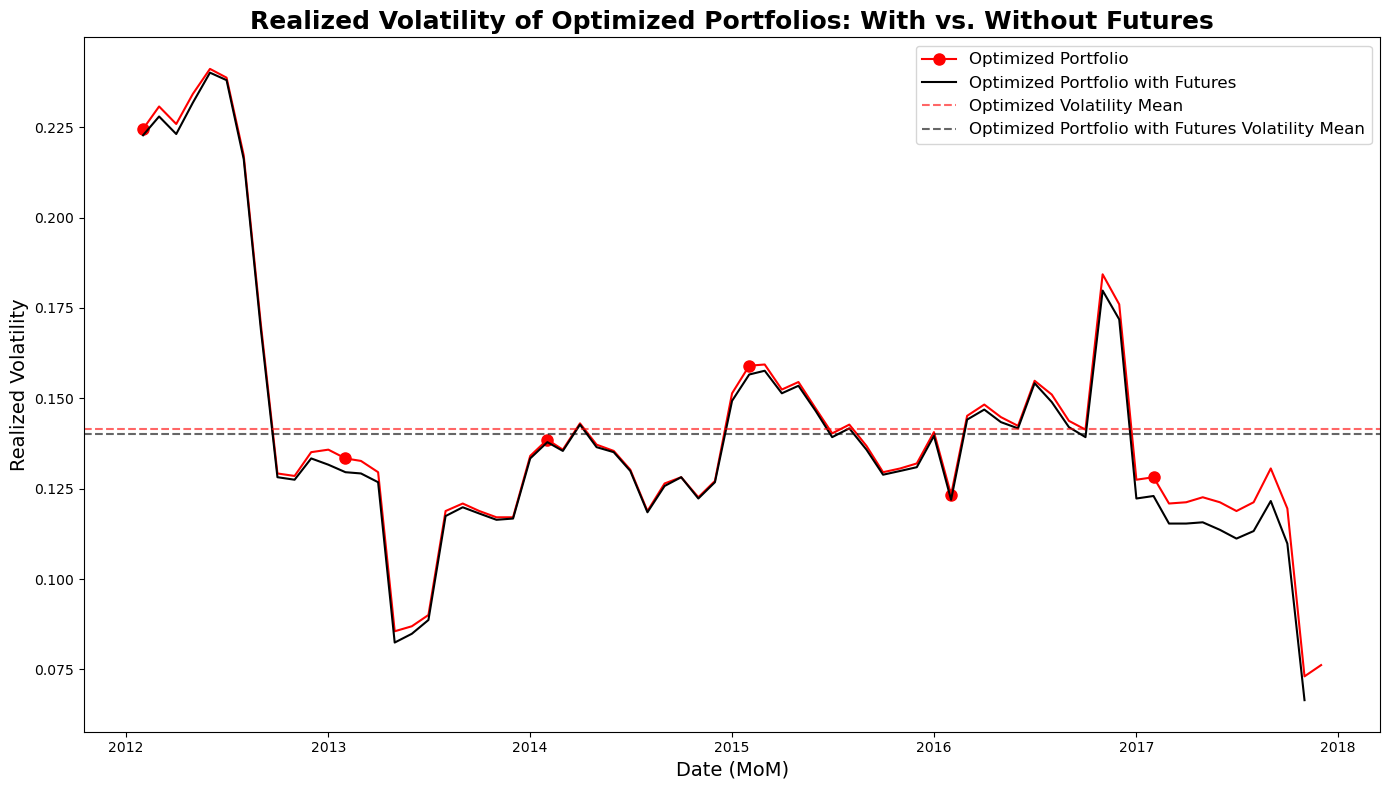

In [506]:
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(rebal_vol.index, rebal_vol['Monthly Volatility'], label='Optimized Portfolio', color='red', marker = 'o', markersize=8, markevery=12)
ax.plot(portf_f_vol.index, portf_f_vol['Monthly Volatility'], label='Optimized Portfolio with Futures', color='black')
ax.set_title('Realized Volatility of Optimized Portfolios: With vs. Without Futures', fontsize=18, weight='bold')
ax.set_xlabel('Date (MoM)', fontsize=14)
ax.set_ylabel('Realized Volatility', fontsize=14)

vol_avg = rebal_vol['Monthly Volatility'].mean()
ax.axhline(y=vol_avg, color='red', linestyle='--', alpha=0.6, label='Optimized Volatility Mean')
vol_avg1 = portf_f_vol['Monthly Volatility'].mean()
ax.axhline(y=vol_avg1, color='black', linestyle='--', alpha=0.6, label='Optimized Portfolio with Futures Volatility Mean')
ax.legend(fontsize=12)
plt.tight_layout()

plt.show()

### SHARPE AND SORTINO

In [554]:
rolling_pl1 = rolling_pl.copy()

In [63]:
def fill_rows(df_list):
    for i in range(len(df_list)):  
        df_test = df_list[i].copy()
        new_date = pd.to_datetime('2019-01-01')
        next_row = df_test[df_test.index > new_date].sort_index().iloc[0]
        df_test.loc[new_date]=next_row
        new_date1 = pd.to_datetime('2020-02-01')
        next_row1 = df_test[df_test.index > new_date1].sort_index().iloc[0]
        df_test.loc[new_date1]=next_row1
        df_test.sort_index(inplace=True)
        oos1_list[i] = df_test.copy()

In [599]:
oos1_list[0].iloc[0]['Optimized Portfolio'] = 1.000000

In [601]:
len(oos1_list[0])

84

In [600]:
oos1_list[0].style.set_sticky()

,SP_500,Optimized Portfolio
Date,,
2012-01-01 00:00:00,1.000000,1.000000
2012-02-01 00:00:00,1.040589,1.040381
2012-03-01 00:00:00,1.040589,1.040381
2012-04-01 00:00:00,1.073193,1.047225
2012-05-01 00:00:00,1.065147,1.035107
2012-06-01 00:00:00,0.998414,0.963217
2012-07-01 00:00:00,1.037907,1.000286
2012-08-01 00:00:00,1.050982,0.979474
2012-09-01 00:00:00,1.071753,1.036037


In [555]:
cumulative_exp_return,yoy_exp_return,sim_one_percentile=cumulative_returns_cal(oos1_list)
sharpe_simulation,sharpe_list_sim,sharpe_spy=list_sharpe_ratio(oos1_list)
print(f'The sharpe ratio of the portfolio on average:{sharpe_simulation}')
print(f'The sharpe ratio of the sp500 : {sharpe_spy}')

DH
DH
The sharpe ratio of the portfolio on average:0    0.648347
dtype: float64
The sharpe ratio of the sp500 : 0.7437961725964073


In [114]:
cumulative_exp_return,yoy_exp_return,sim_one_percentile=cumulative_returns_cal(oos1_list)
sortino_simulation,sortino_list_sim,sortino_spy=list_sortino_ratio(oos1_list)
print(f'The sortino ratio of the portfolio on average:{sortino_simulation}')
print(f'The sortino ratio of the sp500 : {sortino_spy}')

The sortino ratio of the portfolio on average:0    1.090412
dtype: float64
The sortino ratio of the sp500 : 0.9672595796169353


In [82]:
oos1_list1 = oos1_list.copy()

In [83]:
df = oos1_list[0].copy()

In [84]:
df["Normalized P/L"] = [pl / (1_000_000 * val) for pl, val in zip(rolling_pl, df["Optimized Portfolio"])]
df['Optimized Portfolio'] = df['Optimized Portfolio'] + df['Normalized P/L']
df = df.drop(columns = ['Normalized P/L'])
df

,SP_500,Optimized Portfolio
Date,,
2019-01-01,1.000000,1.000498
2019-02-01,1.000000,1.000011
2019-03-01,1.029729,1.042449
2019-04-01,1.048186,1.060727
2019-05-01,1.089393,1.102242
...,...,...
2024-08-01,2.024207,2.373392
2024-09-01,2.070430,2.425947
2024-10-01,2.112247,2.463108


In [85]:
df.style.set_sticky()

,SP_500,Optimized Portfolio
Date,,
2019-01-01 00:00:00,1.000000,1.000498
2019-02-01 00:00:00,1.000000,1.000011
2019-03-01 00:00:00,1.029729,1.042449
2019-04-01 00:00:00,1.048186,1.060727
2019-05-01 00:00:00,1.089393,1.102242
2019-06-01 00:00:00,1.017735,1.037079
2019-07-01 00:00:00,1.087888,1.113453
2019-08-01 00:00:00,1.102169,1.136293
2019-09-01 00:00:00,1.082229,1.124512


In [561]:
oos1_list[0] = df.copy()

In [562]:
oos1_list[0].style.set_sticky()

Ticker,SP_500,Optimized Portfolio
Date,,
2019-01-01 00:00:00,1.000000,0.999545
2019-02-01 00:00:00,1.000000,1.000109
2019-03-01 00:00:00,1.029729,1.057602
2019-04-01 00:00:00,1.048186,1.058763
2019-05-01 00:00:00,1.089393,1.115903
2019-06-01 00:00:00,1.017735,1.017632
2019-07-01 00:00:00,1.087888,1.113426
2019-08-01 00:00:00,1.102169,1.149497
2019-09-01 00:00:00,1.082229,1.046357


In [564]:
cumulative_exp_return,yoy_exp_return,sim_one_percentile=cumulative_returns_cal(oos1_list)
sharpe_simulation,sharpe_list_sim,sharpe_spy=list_sharpe_ratio(oos1_list)
print(f'The sharpe ratio of the portfolio on average (hedged):{sharpe_simulation}')
print(f'The sharpe ratio of the sp500 (hedged): {sharpe_spy}')

DH
DH
The sharpe ratio of the portfolio on average (hedged):0    0.647106
dtype: float64
The sharpe ratio of the sp500 (hedged): 0.7437961725964073


In [86]:
cumulative_exp_return,yoy_exp_return,sim_one_percentile=cumulative_returns_cal(oos1_list)
sortino_simulation,sortino_list_sim,sortino_spy=list_sortino_ratio(oos1_list)
print(f'The sortino ratio of the portfolio on average (hedged):{sortino_simulation}')
print(f'The sortino ratio of the sp500 (hedged): {sortino_spy}')

The sortino ratio of the portfolio on average (hedged):0    1.555274
dtype: float64
The sortino ratio of the sp500 (hedged): 1.075242117664807


In [ ]:
# reset back to orginal oos1_list
oos1_list = oos1_list1.copy()

### ABS^2 DIFF OF BETAS

In [182]:
total_ff3_f_1 = total_ff3_f.T

In [183]:
total_ff3_nof_1 = total_ff3_nof.T

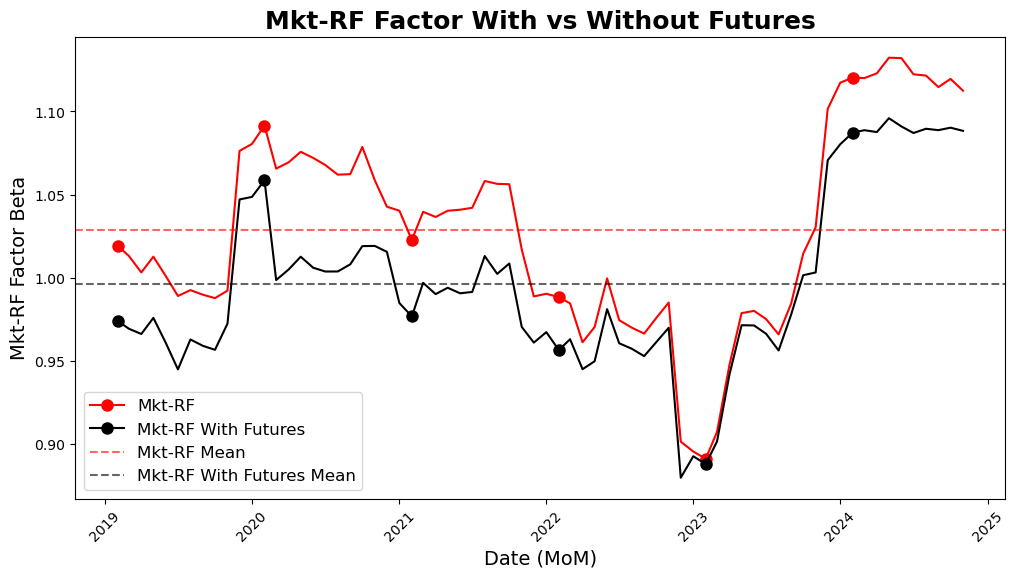

In [184]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(total_ff3_nof_1.index, total_ff3_nof_1['Mkt-RF'], label='Mkt-RF', color='red', marker = 'o', markersize=8, markevery=12)

ax.plot(total_ff3_f_1.index, total_ff3_f_1['Mkt-RF'], label='Mkt-RF With Futures', color='black', marker = 'o', markersize=8, markevery=12)

ax.set_xlabel('Date (MoM)', fontsize=14)
ax.set_ylabel('Mkt-RF Factor Beta', fontsize = 14)
ax.set_title('Mkt-RF Factor With vs Without Futures', fontsize = 18, weight='bold')

plt.xticks(rotation=45)
mkt_avg = total_ff3_nof_1['Mkt-RF'].mean()
ax.axhline(y=mkt_avg, color='red', linestyle='--', alpha=0.6, label='Mkt-RF Mean')
mkt_avg1 = total_ff3_f_1['Mkt-RF'].mean()
ax.axhline(y=mkt_avg1, color='black', linestyle='--', alpha=0.6, label='Mkt-RF With Futures Mean')
ax.legend(fontsize=12)

plt.show()

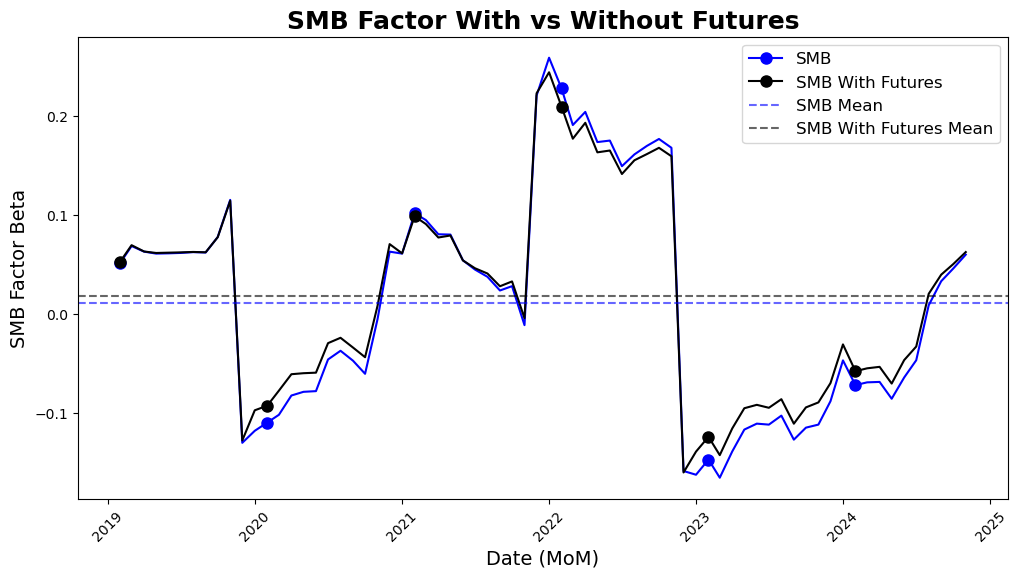

In [185]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(total_ff3_nof_1.index, total_ff3_nof_1['SMB'], label='SMB', color='blue', marker = 'o', markersize=8, markevery=12)
ax.plot(total_ff3_f_1.index, total_ff3_f_1['SMB'], label='SMB With Futures', color='black', marker = 'o', markersize=8, markevery=12)

ax.set_xlabel('Date (MoM)', fontsize=14)
ax.set_ylabel('SMB Factor Beta', fontsize = 14)
ax.set_title('SMB Factor With vs Without Futures', fontsize = 18, weight='bold')

plt.xticks(rotation=45)
smb_avg = total_ff3_nof_1['SMB'].mean()
ax.axhline(y=smb_avg, color='blue', linestyle='--', alpha=0.6, label='SMB Mean')
smb1_avg = total_ff3_f_1['SMB'].mean()
ax.axhline(y=smb1_avg, color='black', linestyle='--', alpha=0.6, label='SMB With Futures Mean')
ax.legend(fontsize=12)

plt.show()

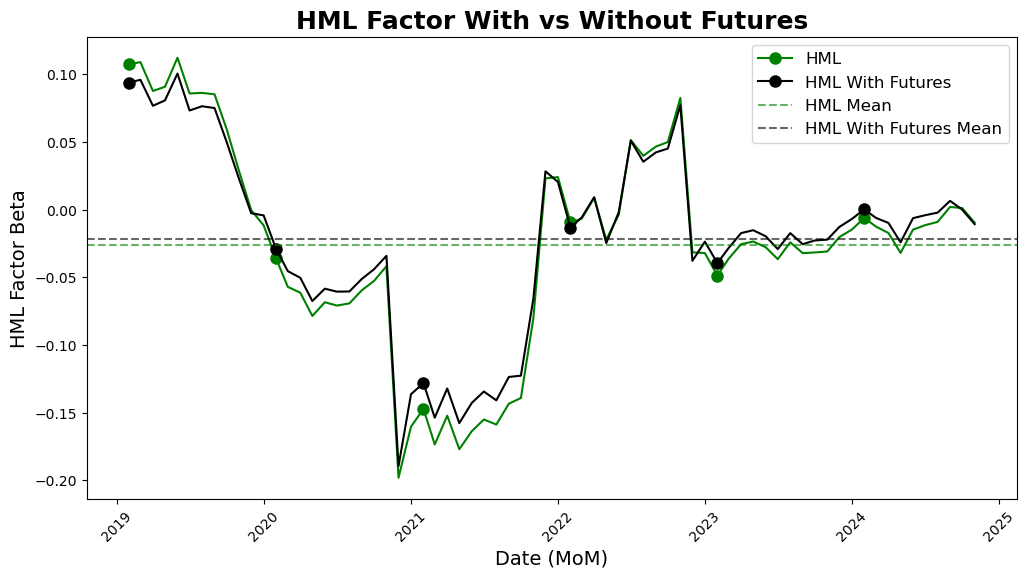

In [186]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(total_ff3_nof_1.index, total_ff3_nof_1['HML'], label='HML', color='green', marker = 'o', markersize=8, markevery=12)
ax.plot(total_ff3_f_1.index, total_ff3_f_1['HML'], label='HML With Futures', color='black', marker = 'o', markersize=8, markevery=12)

ax.set_xlabel('Date (MoM)', fontsize=14)
ax.set_ylabel('HML Factor Beta', fontsize = 14)
ax.set_title('HML Factor With vs Without Futures', fontsize = 18, weight='bold')

plt.xticks(rotation=45)
hml_avg = total_ff3_nof_1['HML'].mean()
ax.axhline(y=hml_avg, color='green', linestyle='--', alpha=0.6, label='HML Mean')
hml1_avg = total_ff3_f_1['HML'].mean()
ax.axhline(y=hml1_avg, color='black', linestyle='--', alpha=0.6, label='HML With Futures Mean')

ax.legend(fontsize=12)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(rebal_vol.index, rebal_vol['Monthly Volatility'], label='Optimized Portfolio', marker='o', color='red')
ax.plot(portf_f_vol.index, portf_f_vol['Monthly Volatility'], label='Optimized Portfolio with Futures', marker='o', color='black')
ax.set_xlabel('MoM', fontsize = 14)
ax.set_ylabel('Volatility', fontsize = 14)
ax.set_title('Realized Volatility of Optimal Portfolio vs Optimal Portfolio with Futures', fontsize = 16)
ax.legend(fontsize=12)


plt.xticks(rotation=45)
#plt.yscale("log")

plt.show()

In [156]:
def calculate_volatility(weights_df):
    # formula is a sum of all weights^2*var + sum of all covariance
    
    volatility_rebal = weights_df.copy()
    n = 0
    
    volatility_df = pd.DataFrame(columns=["Monthly Volatility"])
    
    for month in weights_df.index:
        # expand end_5_years window each iteration
        start_1_month = month - relativedelta(months = 12)  
        end_1_month = month
        
        # re run prices data for new window (+1 month each iteration)
        
        volatility_prices = extract_stock_data(price_monthly_data, volatility_rebal.columns.tolist(), start_1_month, end_1_month)
        volatility_prices = volatility_prices.interpolate(method='linear', limit_direction='both')
        # log returns
        returns_df = np.log(volatility_prices / volatility_prices.shift(1)).dropna()

        # covariance matrix
        cov_matrix = returns_df.cov()
        tickers_list = volatility_prices.columns.tolist()  

        weights = volatility_rebal.loc[month] 
         
        nonzero_weights = weights.loc[(weights.index.isin(tickers_list)) & (weights != 0)]
        final_tickers = nonzero_weights.index.tolist()  # ignores tickers that are 0 

        cov_matrix_subset = cov_matrix.loc[final_tickers, final_tickers]
        weight_vector = nonzero_weights.to_numpy()

        # matrix multiplication of weight vector and covariance matrix
        portfolio_variance = weight_vector.T @ cov_matrix_subset.to_numpy() @ weight_vector
        monthly_volatility = np.sqrt(portfolio_variance)  

        volatility_df.loc[month] = round(monthly_volatility, 4)*( np.sqrt(12)) # annulaized 
        n += 1
    return volatility_df 

In [154]:
volatility_data.mean()

Monthly Volatility    0.243773
dtype: float64

In [147]:
volatility_data.mean()

Simulated Volatility    NaN
dtype: object

In [118]:
display(volatility_data[t].loc[start_date:end_date])

Ticker,A,AAPL,ABBV,ABT,ACN,ADBE,ADI,ADP,ADSK,AKAM,...,WDAY,WDC,WM,WMT,WYNN,XOM,XYL,YUM,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2015-02-27,42.21,128.46001,60.50000,47.37,90.03000,79.10000,58.54000,88.84000,64.24000,69.510,...,85.50000,106.98,54.48000,83.93,142.50,88.54,35.70,81.11000,91.05000,46.09000
2015-03-31,41.55,124.43000,58.54000,46.33,93.69000,73.94000,63.00000,85.64000,58.64000,71.045,...,84.41000,91.01,54.23000,82.25,125.88,85.00,35.02,78.72000,90.71500,46.29000
2015-04-30,41.37,125.15000,64.66000,46.42,92.65000,76.06000,61.84000,84.54000,56.83000,73.780,...,91.21000,97.74,49.53000,78.05,111.07,87.37,37.02,85.96000,92.08000,44.42000
2015-05-29,41.19,130.28000,66.59000,48.60,96.04000,79.09000,67.96000,85.51000,54.15000,76.270,...,78.92000,97.36,49.65000,74.27,100.69,85.20,36.57,90.11000,109.64000,49.77000
2015-06-30,38.58,125.42500,67.19000,49.08,96.78000,81.01000,64.18500,80.23000,50.07500,69.820,...,76.39000,78.42,46.35000,70.93,98.67,83.20,37.07,90.08000,111.05000,48.22000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-30,142.92,229.00000,196.31000,113.27,341.95001,574.40997,234.84000,275.91000,258.39999,101.840,...,263.19000,65.59,212.03999,77.23,76.88,117.94,137.53,134.92000,345.38000,183.49001
2024-09-30,148.48,233.00000,197.48000,114.01,353.48001,517.78003,230.17000,276.73001,275.48001,100.950,...,244.41000,68.29,207.60001,80.75,95.88,117.22,135.03,139.71001,370.32001,195.38000
2024-10-31,130.31,225.91000,203.87000,113.37,344.82001,478.07999,223.11000,289.23999,283.79999,101.080,...,233.85001,65.31,215.85001,81.95,96.02,116.78,121.78,131.16000,381.97000,178.78000


In [160]:
spy_v = pd.read_csv("SPY_V.csv")
spy_v.index = pd.to_datetime(spy_v.index)
spy_v = spy_v.loc[start_date: end_date]
spy_v = spy_v.resample('MS').mean()
spy_v['DATE SPY_V'] = spy_v['DATE SPY_V']/100


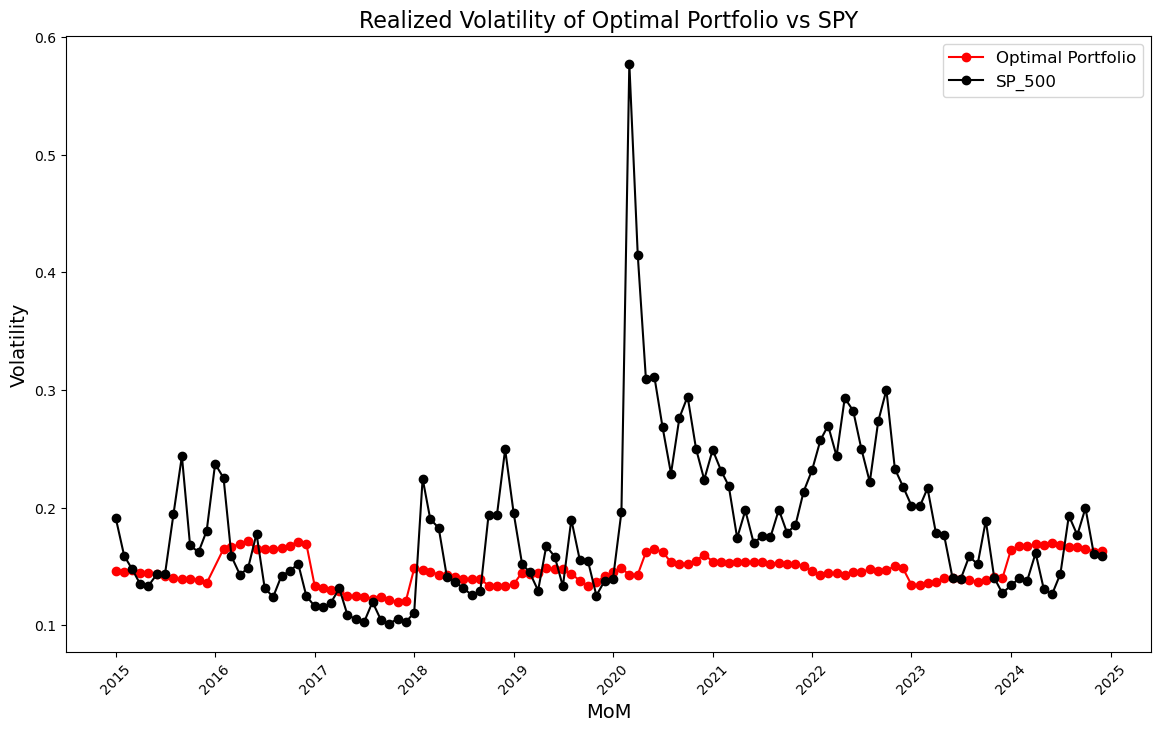

In [ ]:
optimal_volatility = calculate_volatility(rebalance_optimal_weights_appended)
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(optimal_volatility.index, optimal_volatility['Monthly Volatility'], label='Optimal Portfolio', marker='o', color='red')
ax.plot(spy_v.index, spy_v['DATE SPY_V'], label='SP_500', marker='o', color='black')
ax.set_xlabel('MoM', fontsize = 14)
ax.set_ylabel('Volatility', fontsize = 14)
ax.set_title('Realized Volatility of Optimal Portfolio vs SPY', fontsize = 16)
ax.legend(fontsize=12)


plt.xticks(rotation=45)
#plt.yscale("log")

plt.show()

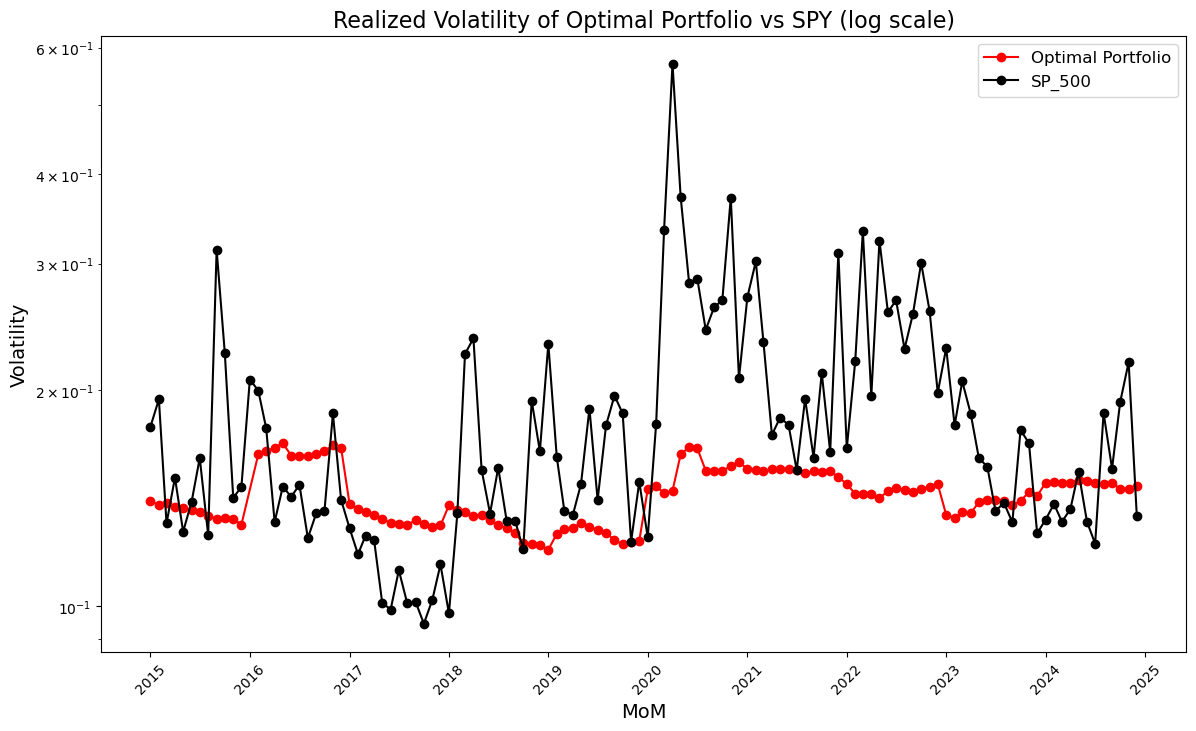

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(optimal_volatility.index, optimal_volatility['Monthly Volatility'], label='Optimal Portfolio', marker='o', color='red')
ax.plot(spy_v.index, spy_v['DATE SPY_V'], label='SP_500', marker='o', color='black')
ax.set_xlabel('MoM', fontsize = 14)
ax.set_ylabel('Volatility', fontsize = 14)
ax.set_title('Realized Volatility of Optimal Portfolio vs SPY (log scale)', fontsize = 16)
ax.legend(fontsize=12)


plt.xticks(rotation=45)
plt.yscale("log")

plt.show()


TypeError: yticks() takes from 0 to 2 positional arguments but 5 were given

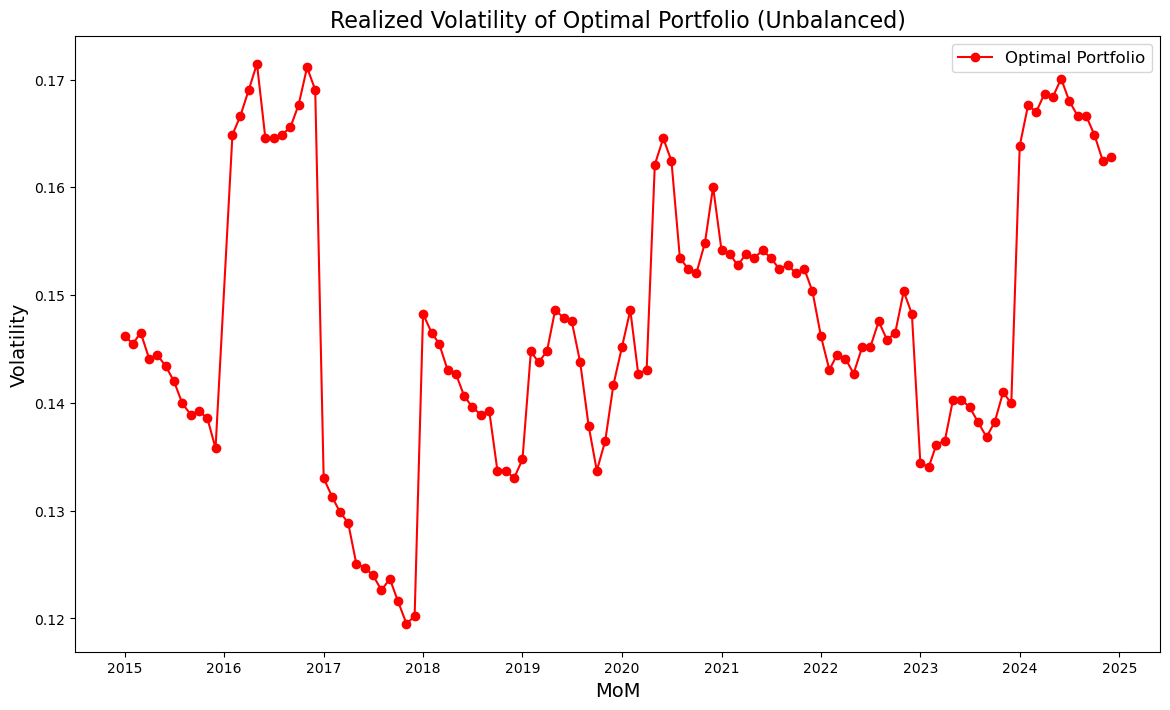

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(optimal_volatility.index, optimal_volatility['Monthly Volatility'], label='Optimal Portfolio', marker='o', color='red')
ax.set_xlabel('MoM', fontsize = 14)
ax.set_ylabel('Volatility', fontsize = 14)
ax.set_title('Realized Volatility of Optimal Portfolio (Unbalanced)', fontsize = 16)
ax.legend(fontsize=12)

plt.yticks(.0, .05, .1, .15, .20)
plt.xticks(rotation=45)
#plt.yscale("log")

plt.show()


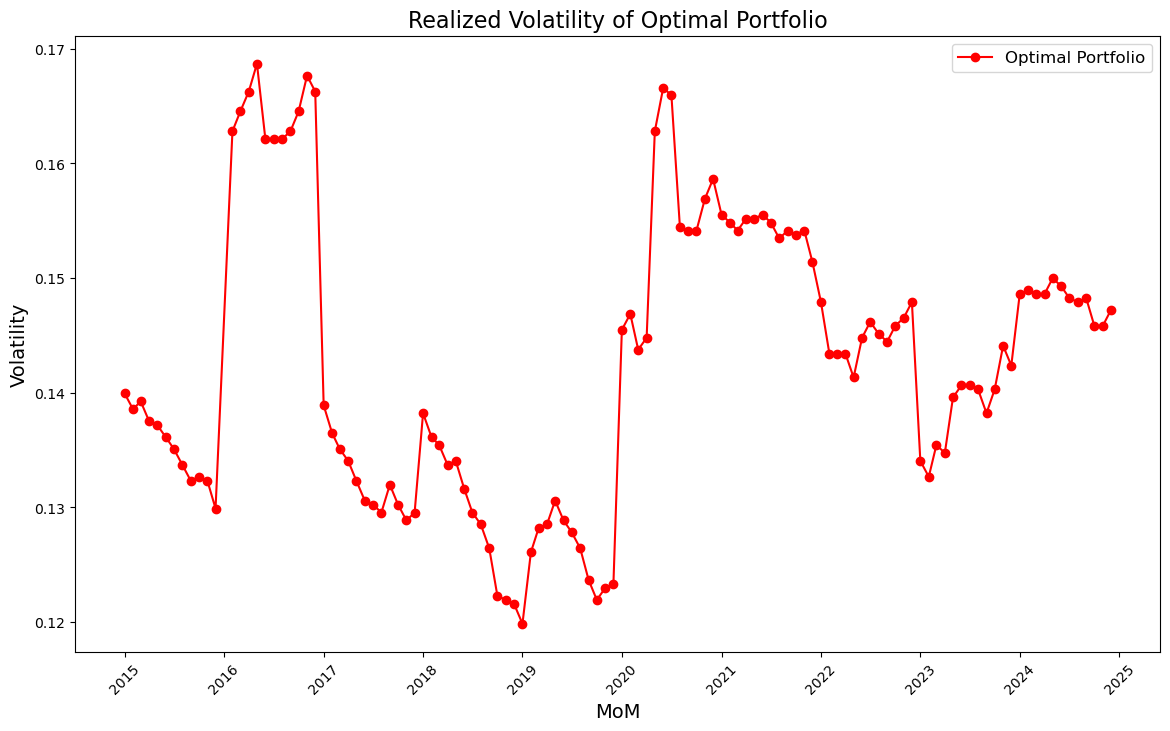

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(optimal_volatility.index, optimal_volatility['Monthly Volatility'], label='Optimal Portfolio', marker='o', color='red')
#ax.plot(spy_v.index, spy_v['DATE SPY_V'], label='SP_500', marker='o', color='black')
ax.set_xlabel('MoM', fontsize = 14)
ax.set_ylabel('Volatility', fontsize = 14)
ax.set_title('Realized Volatility of Optimal Portfolio', fontsize = 16)
ax.legend(fontsize=12)


plt.xticks(rotation=45)
#plt.yscale("log")

plt.show()
